In [1]:
import json
import os
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from shapely.geometry import Point
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def _find_repo_root():
    here = os.getcwd()
    for candidate in (here, os.path.join(here, ".."), os.path.join(here, "..", "..")):
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "data")) and os.path.isdir(os.path.join(candidate, "analysis")):
            return candidate
    raise RuntimeError("Could not locate repo root (expected sibling data/ and analysis/ dirs).")


REPO_ROOT = _find_repo_root()
DATA = os.path.join(REPO_ROOT, "data")

# --- inputs -------------------------------------------------------------
WARD_CENSUS_CSV = os.path.join(DATA, "census", "wards", "toronto-wards.csv")
WARD_GEOJSON = os.path.join(DATA, "geo", "city-wards.geojson")

VENUE_STOPS_CSV = os.path.join(DATA, "activity", "venue_stops.csv")
VENUES_HOMES_CSV = os.path.join(DATA, "activity", "venues_homes.csv")
VENUES_HOMES_MONTHLY_CSV = os.path.join(DATA, "activity", "venues_homes_monthly.csv")
VENUES_GEOHASH9_DIAGNOSTICS_CSV = os.path.join(DATA, "activity", "venues_geohash9_diagnostics.csv")
HOME_SAMPLE_INDEX_CSV = os.path.join(DATA, "activity", "home_sample_index.csv")
TORONTO_MONTH_DENOMS_CSV = os.path.join(DATA, "activity", "toronto_month_denoms.csv")
VENUE_METRICS_JSON = os.path.join(DATA, "activity", "venue_metrics.json")

WARDS_ACTIVITY_DIR = os.path.join(DATA, "activity", "wards")
WARD_TO_VENUE_ACTIVITY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_venue_activity.csv")
WARD_TO_VENUE_SUMMARY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_venue_summary.csv")
WARD_TO_WARD_ACTIVITY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_activity.csv")
WARD_TO_WARD_SUMMARY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_summary.csv")
WARD_TO_WARD_MATRIX_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_matrix.csv")

VENUE_CENTROIDS_GEOJSON = os.path.join(DATA, "venues", "tac-list", "venues-centroids.geojson")
BROADER_INVENTORY_CSV = os.path.join(DATA, "venues", "tac-list", "current_toronto_arts_locations_eddit.csv")

# --- analysis parameters -------------------------------------------------
TIME_PERIOD = "all"  # headline results always use the undivided "all" time period
VALUE_COL = "normalized_raw_stop_count_by_ward"  # ward_to_venue_activity's headline normalized activity field
MERIDIAN_VENUE_NAMES = ["Meridian Arts Centre"]

# geodesy: WGS84 (EPSG:4326) source geometry -> a metric UTM CRS for Toronto,
# using the same `estimate_utm_crs()` approach as analysis/activity/ward_venue_activity.ipynb
# (resolves to EPSG:32617, UTM zone 17N) rather than hard-coding an EPSG code.
GEOHASH6_PRECISION = 6

# --- ward -> region classification (Section 4) ---------------------------
# Grouping follows the City of Toronto's four Community Council areas, the
# current official governance grouping of the 25 wards. This is documented
# and verifiable (not an ad hoc geographic guess), and gives a natural,
# citable "alternative downtown boundary" for a sensitivity check in Section 4.
WARD_REGION = {
    "Etobicoke North": "Etobicoke York",
    "Etobicoke Centre": "Etobicoke York",
    "Etobicoke-Lakeshore": "Etobicoke York",
    "York South-Weston": "Etobicoke York",
    "York Centre": "Etobicoke York",
    "Humber River-Black Creek": "Etobicoke York",
    "Eglinton-Lawrence": "Etobicoke York",
    "Parkdale-High Park": "Toronto and East York",
    "Davenport": "Toronto and East York",
    "Spadina-Fort York": "Toronto and East York",
    "University-Rosedale": "Toronto and East York",
    "Toronto-St. Paul's": "Toronto and East York",
    "Toronto Centre": "Toronto and East York",
    "Toronto-Danforth": "Toronto and East York",
    "Beaches-East York": "Toronto and East York",
    "Don Valley West": "North York",
    "Don Valley East": "North York",
    "Don Valley North": "North York",
    "Willowdale": "North York",
    "Scarborough Southwest": "Scarborough",
    "Scarborough Centre": "Scarborough",
    "Scarborough-Agincourt": "Scarborough",
    "Scarborough North": "Scarborough",
    "Scarborough-Guildwood": "Scarborough",
    "Scarborough-Rouge Park": "Scarborough",
}
SCARBOROUGH_WARDS = [w for w, r in WARD_REGION.items() if r == "Scarborough"]
SUBURBAN_REGIONS = ["Etobicoke York", "North York", "Scarborough"]

# Primary downtown/core definition: the "Toronto and East York" Community Council area.
DOWNTOWN_CORE_WARDS_BROAD = [w for w, r in WARD_REGION.items() if r == "Toronto and East York"]
# Alternative, narrower definition: the old City of Toronto footprint only, excluding
# Beaches-East York (which is the former East York, not former City of Toronto).
DOWNTOWN_CORE_WARDS_NARROW = [w for w in DOWNTOWN_CORE_WARDS_BROAD if w != "Beaches-East York"]

PALETTE = sns.color_palette("colorblind")
REGION_COLORS = dict(zip(["Toronto and East York"] + SUBURBAN_REGIONS, PALETTE))

tqdm.pandas()


# Story 1: Toronto's cultural venues serve residents across ward lines

**Central thesis under test:** (1) residents already travel outside their own ward to use arts venues, and residents from other wards already travel into their ward, and (2) suburban wards already connect to *each other*, not only to downtown.

**Audience:** city councillors, especially those representing suburban wards or wards that look "under-served" by visible cultural infrastructure.

This notebook is self-contained. It reuses definitions and QA methods established in `analysis/wards/explore_census_activity_data.ipynb`, but recomputes everything from the raw data files rather than depending on that notebook's in-memory variables.

## 1. What this notebook measures

- **Origin ward**: the inferred home ward of observed mobile devices, from a geohash6 home-area assigned to each device with at least a minimum confidence threshold (established upstream, not recomputed here).
- **Destination ward**: the ward containing an included arts venue.
- **A "flow" from Ward A to Ward B** means *normalized activity associated with residents of A, recorded at included venues in B*. It is **not** a directly observed door-to-door trip — no single trip is tracked.
- **Normalized raw-stop activity** (our headline metric) is a sample-normalized count of location "stops" at a venue. It is **not** attendance, a unique-person count, or a percentage of residents participating. It scales with how much a venue attracts device presence in a sample of mobile devices, adjusted for sample-size drift over time and geography.
- **The 105 venues with activity data** are a selected study sample, not an exhaustive list of Toronto's arts venues.
- **The broader ~2,576-location inventory** (`current_toronto_arts_locations_eddit.csv`) is a spatial inventory of arts-related locations with no activity/visitation measurements attached.
- **Absence from either dataset does not demonstrate absence of cultural activity** at a location or in a ward.
- **Ward-level demographic relationships are ecological.** A correlation between a ward's demographic makeup and its activity pattern describes the ward as a unit, not the individuals who make up the observed activity.

We default to `time_period == "all"` throughout for headline figures, and do not add `all` together with any weekday/weekend or daytime/evening subset (these are overlapping, non-exhaustive categorizations, not additive slices).


In [3]:
# --- load ward census (authoritative population) --------------------------
census_long = pd.read_csv(WARD_CENSUS_CSV)
pop_row = census_long[census_long["CHARACTERISTIC_ID"] == 1]  # "Population, 2021"
ward_pop = pop_row[["ward_code", "ward_name", "C1_COUNT_TOTAL"]].rename(columns={"C1_COUNT_TOTAL": "population_2021"})
ward_pop["ward_code"] = ward_pop["ward_code"].astype(str).str.zfill(2)
assert ward_pop.shape[0] == 25, f"expected 25 wards, got {ward_pop.shape[0]}"
assert ward_pop["ward_code"].is_unique
ward_pop["region"] = ward_pop["ward_name"].map(WARD_REGION)
assert ward_pop["region"].isna().sum() == 0, "every ward must map to a region"

# --- load ward flow tables, renaming ambiguous columns for clarity ---------
# None of these five precomputed ward_to_* tables carry a time_period column at
# all: they are already built at time_period == "all" only (confirmed below by
# row counts: 105 venues x 25 wards = 2625 dense rows in ward_to_venue_activity).
# ward_to_venue_activity: ward_name=origin ward, venue_ward=destination ward,
# home_ward (bool)=whether origin==destination for this row.
ward_to_venue_activity = pd.read_csv(WARD_TO_VENUE_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward", "home_ward": "is_home_ward",
    "normalized_raw_stop_count_by_ward_pct": "pct_of_venue_total",
})
# ward_to_venue_summary: home_ward here means the VENUE's own ward (destination side),
# confirmed against venue_ward in ward_to_venue_activity above -> rename to dest_ward.
ward_to_venue_summary = pd.read_csv(WARD_TO_VENUE_SUMMARY_CSV).rename(columns={"home_ward": "dest_ward"})
# ward_to_ward_activity: one row per (origin, destination) ward pair.
ward_to_ward_activity = pd.read_csv(WARD_TO_WARD_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward",
})
# ward_to_ward_summary: one row per ORIGIN ward, within/outside-ward split of residents' activity.
ward_to_ward_summary = pd.read_csv(WARD_TO_WARD_SUMMARY_CSV).rename(columns={"ward_name": "origin_ward"})
# ward_to_ward_matrix: origin (rows) x destination (columns) normalized activity matrix.
ward_to_ward_matrix = pd.read_csv(WARD_TO_WARD_MATRIX_CSV).rename(columns={"ward_name": "origin_ward"}).set_index("origin_ward")

for name, df in [("ward_to_venue_activity", ward_to_venue_activity), ("ward_to_venue_summary", ward_to_venue_summary),
                  ("ward_to_ward_activity", ward_to_ward_activity), ("ward_to_ward_summary", ward_to_ward_summary),
                  ("ward_to_ward_matrix", ward_to_ward_matrix)]:
    print(f"{name}: {df.shape}")
print("\nno time_period column on any ward_to_* table -> pre-built at time_period == 'all' only")


ward_to_venue_activity: (2625, 9)
ward_to_venue_summary: (105, 9)
ward_to_ward_activity: (625, 6)
ward_to_ward_summary: (25, 5)
ward_to_ward_matrix: (25, 25)

no time_period column on any ward_to_* table -> pre-built at time_period == 'all' only


In [4]:
# --- condensed QA: keys, coverage, reconciliation --------------------------
# 1. all 25 wards appear as both origin and destination
assert set(ward_to_ward_summary["origin_ward"]) == set(ward_pop["ward_name"])
assert set(ward_to_ward_matrix.index) == set(ward_pop["ward_name"])
assert set(ward_to_ward_matrix.columns) == set(ward_pop["ward_name"])

# 2. dense cross-join: ward_to_venue_activity should have one row per (venue, ward) pair
n_venues = ward_to_venue_activity["venue_id"].nunique()
assert ward_to_venue_activity.shape[0] == n_venues * 25, "expected a dense venue x ward cross-join"

# 3. matrix reconciles with ward_to_ward_activity (same totals, two representations)
matrix_long = ward_to_ward_matrix.reset_index().melt(id_vars="origin_ward", var_name="dest_ward", value_name="value_from_matrix")
check = ward_to_ward_activity.merge(matrix_long, on=["origin_ward", "dest_ward"])
max_diff = (check["normalized_raw_stop_count_by_ward"] - check["value_from_matrix"]).abs().max()
print(f"max abs diff, ward_to_ward_activity vs. matrix: {max_diff:.2e}")
assert max_diff < 1e-6

# 4. ward_to_ward_summary's within/outside totals reconcile with ward_to_ward_activity's same_ward flag
agg_check = ward_to_ward_activity.groupby(["origin_ward", "same_ward"], as_index=False)["normalized_raw_stop_count_by_ward"].sum()
within = agg_check[agg_check["same_ward"]].set_index("origin_ward")["normalized_raw_stop_count_by_ward"]
outside = agg_check[~agg_check["same_ward"]].groupby("origin_ward")["normalized_raw_stop_count_by_ward"].sum()
recon = ward_to_ward_summary.set_index("origin_ward")
within_diff = (recon["normalized_raw_stop_count_within_ward"] - within).abs().max()
outside_diff = (recon["normalized_raw_stop_count_outside_ward"] - outside).abs().max()
print(f"max abs diff, within-ward reconciliation: {within_diff:.2e}")
print(f"max abs diff, outside-ward reconciliation: {outside_diff:.2e}")
assert within_diff < 1e-6 and outside_diff < 1e-6

# 5. no missing/negative values in the headline activity columns
for df, col in [(ward_to_ward_summary, "normalized_raw_stop_count_within_ward"),
                (ward_to_ward_summary, "normalized_raw_stop_count_outside_ward"),
                (ward_to_venue_activity, "normalized_raw_stop_count_by_ward")]:
    assert df[col].notna().all() and (df[col] >= 0).all()

print("\nAll ward-table QA checks passed: 25/25 wards present, dense cross-join confirmed, "
      "matrix/activity/summary tables reconcile to within numerical tolerance, no missing or negative values.")


max abs diff, ward_to_ward_activity vs. matrix: 0.00e+00
max abs diff, within-ward reconciliation: 0.00e+00
max abs diff, outside-ward reconciliation: 4.55e-13

All ward-table QA checks passed: 25/25 wards present, dense cross-join confirmed, matrix/activity/summary tables reconcile to within numerical tolerance, no missing or negative values.


In [5]:
# --- venue metadata: coordinates, ward assignment, funding flags -----------
with open(VENUE_CENTROIDS_GEOJSON) as f:
    _centroids = json.load(f)
venue_meta = pd.json_normalize([f["properties"] | {"lon": f["geometry"]["coordinates"][0],
                                                     "lat": f["geometry"]["coordinates"][1]}
                                 for f in _centroids["features"]])
venue_meta["venue_id"] = venue_meta["id"].astype(int)
venue_meta = venue_meta.drop(columns=["id", "fid"])

with open(VENUE_METRICS_JSON) as f:
    venue_metrics_raw = json.load(f)
venue_metrics = pd.DataFrame([{
    "venue_id": v["venue_id"], "venue_name": v["venue_name"],
    "home_origin_hhi": v["home_origin_hhi"],
    "weekday_pct": v["weekday_weekend_split"]["weekday_pct"],
    "weekend_pct": v["weekday_weekend_split"]["weekend_pct"],
    "nine_five_pct": v["daytime_evening_split"]["nine_five_pct"],
    "evening_pct": v["daytime_evening_split"]["evening_pct"],
    **{f"dist_{k}": v["travel_distance_distribution"][k] for k in v["travel_distance_distribution"]},
} for v in venue_metrics_raw])

assert venue_meta["venue_id"].nunique() == 105 == venue_metrics["venue_id"].nunique()
print(f"venue_meta: {venue_meta.shape}, venue_metrics: {venue_metrics.shape}")

# map each venue to its destination ward, from ward_to_venue_activity (already verified against venue_meta coords below)
venue_to_dest_ward = ward_to_venue_activity.loc[ward_to_venue_activity["is_home_ward"], ["venue_id", "venue_name", "dest_ward"]].drop_duplicates()
assert venue_to_dest_ward["venue_id"].is_unique
print(f"venue_to_dest_ward: {venue_to_dest_ward.shape[0]} venues mapped to a single destination ward each")

# --- mapped vs. eligible home-origin totals (unmapped-origin remainder) ----
total_mapped = ward_to_venue_activity["normalized_raw_stop_count_by_ward"].sum()
venue_stops_all = pd.read_csv(VENUE_STOPS_CSV)
venue_stops_all = venue_stops_all[venue_stops_all["time_period"] == TIME_PERIOD]
total_eligible = venue_stops_all["normalized_raw_stop_count"].sum()
print(f"\ntotal normalized activity mapped to an origin ward : {total_mapped:,.0f}")
print(f"total normalized activity, all included venues (time_period=all): {total_eligible:,.0f}")
print(f"share of citywide normalized activity mapped to a home ward: {total_mapped / total_eligible:.1%}")
print("(the remainder has no confident home-geohash match and is excluded from ward-to-ward flow analysis, "
      "not because those devices demonstrably live outside Toronto)")


venue_meta: (105, 18), venue_metrics: (105, 11)
venue_to_dest_ward: 105 venues mapped to a single destination ward each

total normalized activity mapped to an origin ward : 115,058
total normalized activity, all included venues (time_period=all): 189,151
share of citywide normalized activity mapped to a home ward: 60.8%
(the remainder has no confident home-geohash match and is excluded from ward-to-ward flow analysis, not because those devices demonstrably live outside Toronto)


In [6]:
# --- load authoritative ward geometry, verify venue-ward assignment spatially --
wards_gdf_raw = gpd.read_file(WARD_GEOJSON)
wards_gdf = wards_gdf_raw[wards_gdf_raw.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
assert wards_gdf.shape[0] == 25, f"expected 25 ward polygons, got {wards_gdf.shape[0]}"
if wards_gdf.crs is None:
    wards_gdf = wards_gdf.set_crs("EPSG:4326")
UTM_CRS = wards_gdf.estimate_utm_crs()
print(f"estimated UTM CRS for metric distance work: {UTM_CRS}")

venue_points = gpd.GeoDataFrame(
    venue_meta[["venue_id", "venue_name", "lat", "lon"]],
    geometry=gpd.points_from_xy(venue_meta["lon"], venue_meta["lat"]), crs="EPSG:4326",
)
venue_ward_spatial = gpd.sjoin(venue_points, wards_gdf[["ward_name", "geometry"]], predicate="within")[["venue_id", "ward_name"]]
venue_ward_spatial = venue_ward_spatial.rename(columns={"ward_name": "dest_ward_spatial"})

_check = venue_to_dest_ward.merge(venue_ward_spatial, on="venue_id", how="left")
_mismatch = _check[_check["dest_ward"] != _check["dest_ward_spatial"]]
print(f"venues matched to a ward by point-in-polygon spatial join: {venue_ward_spatial.shape[0]} / 105")
print(f"venues where the activity table's dest_ward disagrees with the spatial join: {_mismatch.shape[0]}")
if len(_mismatch):
    display(_mismatch)


estimated UTM CRS for metric distance work: EPSG:32617
venues matched to a ward by point-in-polygon spatial join: 105 / 105
venues where the activity table's dest_ward disagrees with the spatial join: 0


## 2. A two-sided ward reach table

Every ward plays two roles at once: a source of residents' activity (**origin side**), and a host of venues that activity flows into (**destination side**). We build one 25-row table capturing both.

**Concentration measure.** For "how many destinations/origins matter," we use the *effective number of destinations* $N_{eff} = 1/HHI$, where $HHI = \sum_i s_i^2$ over each ward's shares $s_i$ of outside-ward activity. This is more interpretable for a councillor than a bare HHI: an $N_{eff}$ of 3 means a ward's outside-ward activity is about as concentrated as if it were split evenly across 3 destinations (even though the true split may be uneven).

**Net flow** below is a descriptive balance of normalized activity units only — *not* a measure of economic value, cultural benefit, or "who owes whom."


In [7]:
def hhi(shares):
    return float(np.sum(np.square(shares)))


def effective_n(shares):
    h = hhi(shares)
    return float("nan") if h == 0 else 1.0 / h


# --- origin-side measures ---------------------------------------------------
origin_rows = []
for ward, grp in ward_to_ward_activity.groupby("origin_ward"):
    total = grp["normalized_raw_stop_count_by_ward"].sum()
    outside = grp.loc[~grp["same_ward"]]
    outside_total = outside["normalized_raw_stop_count_by_ward"].sum()
    outside_shares = (outside["normalized_raw_stop_count_by_ward"] / outside_total) if outside_total > 0 else pd.Series(dtype=float)
    top = outside.sort_values("normalized_raw_stop_count_by_ward", ascending=False).iloc[0] if len(outside) else None
    n_meaningful = int((outside["normalized_raw_stop_count_by_ward"] / outside_total >= 0.05).sum()) if outside_total > 0 else 0
    downtown_share = outside.loc[outside["dest_ward"].isin(DOWNTOWN_CORE_WARDS_BROAD), "normalized_raw_stop_count_by_ward"].sum() / outside_total if outside_total > 0 else np.nan
    suburb_share = outside.loc[~outside["dest_ward"].isin(DOWNTOWN_CORE_WARDS_BROAD), "normalized_raw_stop_count_by_ward"].sum() / outside_total if outside_total > 0 else np.nan
    same_region = outside.loc[outside["dest_ward"].map(WARD_REGION) == WARD_REGION[ward], "normalized_raw_stop_count_by_ward"].sum() / outside_total if outside_total > 0 else np.nan
    origin_rows.append({
        "ward_name": ward,
        "origin_total_activity": total,
        "origin_within_ward_share": 1 - outside_total / total if total > 0 else np.nan,
        "origin_outside_ward_share": outside_total / total if total > 0 else np.nan,
        "leading_outside_dest_ward": top["dest_ward"] if top is not None else None,
        "leading_outside_dest_share": (top["normalized_raw_stop_count_by_ward"] / outside_total) if top is not None and outside_total > 0 else np.nan,
        "n_meaningful_dest_wards": n_meaningful,
        "dest_effective_n": effective_n(outside_shares.values) if len(outside_shares) else np.nan,
        "origin_to_downtown_share": downtown_share,
        "origin_to_suburb_share": suburb_share,
        "origin_to_same_region_share": same_region,
    })
origin_side = pd.DataFrame(origin_rows)
origin_side.sort_values("origin_outside_ward_share", ascending=False).head(8)


,ward_name,origin_total_activity,origin_within_ward_share,origin_outside_ward_share,leading_outside_dest_ward,leading_outside_dest_share,n_meaningful_dest_wards,dest_effective_n,origin_to_downtown_share,origin_to_suburb_share,origin_to_same_region_share
4,Don Valley West,"2,787.11",0.00,1.00,Willowdale,0.54,4,2.95,0.38,0.62,0.56
13,Scarborough Southwest,"2,850.85",0.00,1.00,University-Rosedale,0.28,6,5.34,0.80,0.20,0.08
24,York South-Weston,"2,943.60",0.00,1.00,University-Rosedale,0.44,5,3.92,0.77,0.23,0.07
15,Scarborough-Guildwood,"1,167.95",0.03,0.97,University-Rosedale,0.18,6,8.15,0.47,0.53,0.26
19,Toronto-Danforth,"3,163.55",0.08,0.92,Toronto Centre,0.23,6,5.47,0.91,0.09,0.91
2,Don Valley East,"2,135.24",0.08,0.92,Spadina-Fort York,0.28,5,5.05,0.62,0.38,0.33
23,York Centre,"3,085.82",0.09,0.91,Willowdale,0.48,4,2.98,0.46,0.54,0.05
8,Etobicoke-Lakeshore,"1,513.26",0.11,0.89,Spadina-Fort York,0.28,4,5.31,0.79,0.21,0.05


In [8]:
# --- destination-side measures ----------------------------------------------
venues_per_ward = venue_to_dest_ward.groupby("dest_ward").size().rename("n_venues")

dest_rows = []
for ward, grp in ward_to_ward_activity.groupby("dest_ward"):
    total = grp["normalized_raw_stop_count_by_ward"].sum()
    outside = grp.loc[~grp["same_ward"]]
    outside_total = outside["normalized_raw_stop_count_by_ward"].sum()
    outside_shares = (outside["normalized_raw_stop_count_by_ward"] / outside_total) if outside_total > 0 else pd.Series(dtype=float)
    top = outside.sort_values("normalized_raw_stop_count_by_ward", ascending=False).iloc[0] if len(outside) else None
    ward_venues = venue_to_dest_ward.loc[venue_to_dest_ward["dest_ward"] == ward, "venue_id"]
    venue_totals = ward_to_venue_summary.loc[ward_to_venue_summary["venue_id"].isin(ward_venues)]
    venue_totals = venue_totals.assign(total=lambda d: d["normalized_raw_stop_count_by_ward_within_ward"] + d["normalized_raw_stop_count_by_ward_outside_ward"])
    top1_share = venue_totals["total"].max() / venue_totals["total"].sum() if len(venue_totals) else np.nan
    dest_rows.append({
        "ward_name": ward,
        "dest_total_activity": total,
        "dest_within_ward_share": 1 - outside_total / total if total > 0 else np.nan,
        "dest_outside_ward_share": outside_total / total if total > 0 else np.nan,
        "leading_outside_origin_ward": top["origin_ward"] if top is not None else None,
        "leading_outside_origin_share": (top["normalized_raw_stop_count_by_ward"] / outside_total) if top is not None and outside_total > 0 else np.nan,
        "origin_effective_n": effective_n(outside_shares.values) if len(outside_shares) else np.nan,
        "n_venues": int(venues_per_ward.get(ward, 0)),
        "dest_top1_venue_share": top1_share,
    })
dest_side = pd.DataFrame(dest_rows)

# --- combined measures -------------------------------------------------------
ward_reach = origin_side.merge(dest_side, on="ward_name").merge(
    ward_pop[["ward_name", "population_2021", "region"]], on="ward_name")
ward_reach["net_flow"] = ward_reach["dest_total_activity"] - ward_reach["origin_total_activity"]
ward_reach["venues_per_100k"] = ward_reach["n_venues"] / ward_reach["population_2021"] * 1e5


def classify_role(row, med_origin_outside, med_dest_outside):
    high_origin_outside = row["origin_outside_ward_share"] >= med_origin_outside
    high_dest_outside = row["dest_outside_ward_share"] >= med_dest_outside
    if high_origin_outside and high_dest_outside:
        return "mutual exchange hub"
    if high_origin_outside and not high_dest_outside:
        return "exporter of activity"
    if not high_origin_outside and high_dest_outside:
        return "citywide destination"
    return "primarily local"


med_o, med_d = ward_reach["origin_outside_ward_share"].median(), ward_reach["dest_outside_ward_share"].median()
ward_reach["role"] = ward_reach.apply(classify_role, axis=1, args=(med_o, med_d))

# reciprocal ward pairs: A sends meaningfully to B AND B sends meaningfully to A
pair_matrix = ward_to_ward_activity.pivot(index="origin_ward", columns="dest_ward", values="normalized_raw_stop_count_by_ward")
reciprocal_pairs = []
for a, b in combinations(pair_matrix.index, 2):
    a_to_b, b_to_a = pair_matrix.loc[a, b], pair_matrix.loc[b, a]
    if a_to_b > 0 and b_to_a > 0:
        reciprocal_pairs.append({"ward_a": a, "ward_b": b, "a_to_b": a_to_b, "b_to_a": b_to_a,
                                   "two_way_total": a_to_b + b_to_a, "reciprocity": min(a_to_b, b_to_a) / max(a_to_b, b_to_a)})
reciprocal_pairs = pd.DataFrame(reciprocal_pairs).sort_values("two_way_total", ascending=False)

print(f"ward_reach: {ward_reach.shape}")
print(f"\nrole counts:\n{ward_reach['role'].value_counts()}")
print(f"\ntop 8 reciprocal ward pairs by two-way total activity:")
reciprocal_pairs.head(8)


ward_reach: (25, 24)

role counts:
role
mutual exchange hub     7
citywide destination    6
primarily local         6
exporter of activity    6
Name: count, dtype: int64

top 8 reciprocal ward pairs by two-way total activity:


,ward_a,ward_b,a_to_b,b_to_a,two_way_total,reciprocity
221,Spadina-Fort York,Toronto Centre,"4,396.93","2,181.20","6,578.14",0.50
229,Toronto Centre,University-Rosedale,"2,617.62",921.79,"3,539.41",0.35
224,Spadina-Fort York,University-Rosedale,"1,059.87","1,471.26","2,531.13",0.72
94,Don Valley West,Willowdale,"1,506.80",2.00,"1,508.80",0.00
35,Davenport,Spadina-Fort York,819.38,649.95,"1,469.33",0.79
241,Willowdale,York Centre,49.73,"1,347.73","1,397.46",0.04
79,Don Valley North,Willowdale,"1,239.88",54.16,"1,294.04",0.04
169,Parkdale-High Park,Spadina-Fort York,"1,204.45",23.61,"1,228.06",0.02


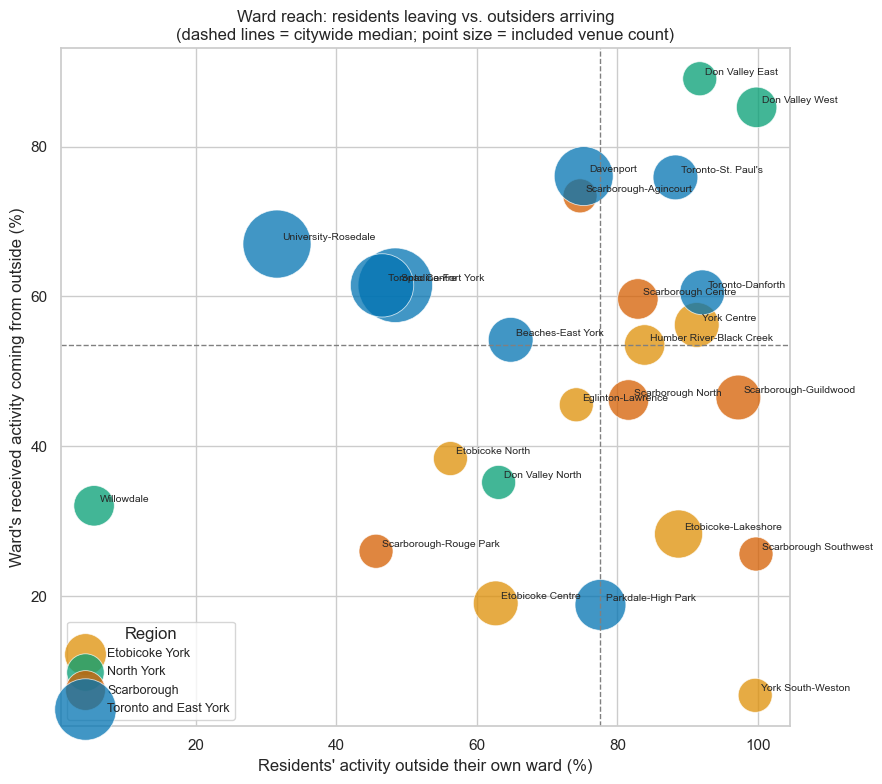

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))
sizes = 200 * ward_reach["n_venues"].clip(lower=1) / ward_reach["n_venues"].clip(lower=1).max()
for region, grp in ward_reach.groupby("region"):
    ax.scatter(grp["origin_outside_ward_share"] * 100, grp["dest_outside_ward_share"] * 100,
               s=200 * (grp["n_venues"].clip(lower=1)) ** 0.5 * 3, alpha=0.75,
               color=REGION_COLORS.get(region), label=region, edgecolor="white", linewidth=0.6)
for _, row in ward_reach.iterrows():
    ax.annotate(row["ward_name"], (row["origin_outside_ward_share"] * 100, row["dest_outside_ward_share"] * 100),
                fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.axvline(med_o * 100, color="grey", linestyle="--", linewidth=1)
ax.axhline(med_d * 100, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Residents' activity outside their own ward (%)")
ax.set_ylabel("Ward's received activity coming from outside (%)")
ax.set_title("Ward reach: residents leaving vs. outsiders arriving\n(dashed lines = citywide median; point size = included venue count)")
ax.legend(title="Region", loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()


In [10]:
print(f"median origin-side outside-ward share across 25 wards: {med_o:.1%}")
print(f"median destination-side outside-ward share across 25 wards: {med_d:.1%}")
print(ward_reach[["ward_name", "region", "n_venues", "origin_outside_ward_share", "dest_outside_ward_share", "role"]]
      .sort_values("origin_outside_ward_share", ascending=False).to_string(index=False))


median origin-side outside-ward share across 25 wards: 77.6%
median destination-side outside-ward share across 25 wards: 53.5%
               ward_name                region  n_venues  origin_outside_ward_share  dest_outside_ward_share                 role
         Don Valley West            North York         2                       1.00                     0.85  mutual exchange hub
   Scarborough Southwest           Scarborough         1                       1.00                     0.26 exporter of activity
       York South-Weston        Etobicoke York         1                       1.00                     0.07 exporter of activity
   Scarborough-Guildwood           Scarborough         3                       0.97                     0.47 exporter of activity
        Toronto-Danforth Toronto and East York         3                       0.92                     0.61  mutual exchange hub
         Don Valley East            North York         1                       0.92          

**Findings.** Roles split roughly evenly across the 25 wards: 7 "mutual exchange hubs" (high on both axes), 6 "citywide destinations," 6 "exporters of activity," and 6 "primarily local" wards. Every region (Etobicoke York, North York, Scarborough, Toronto and East York) has wards in more than one role — no region is uniformly self-contained or uniformly outward-looking. The unweighted median origin-side outside-ward share across the 25 wards (`med_o`) is noticeably higher than the citywide activity-weighted figure reproduced in Section 3 below; that gap is itself a finding (Section 3 explains why).

Reciprocal ward pairs are dominated by adjacent downtown wards (Spadina-Fort York ↔ Toronto Centre ↔ University-Rosedale) with moderate-to-high reciprocity (0.35–0.72). Several large two-way totals (e.g., Don Valley West ↔ Willowdale, Willowdale ↔ York Centre) have reciprocity near 0 — these are not really "exchanges," just one ward's residents visiting a dominant venue in another ward with almost nothing flowing back; we flag this rather than calling it an exchange.

**Takeaway.** The four-way role split is a genuinely more informative story frame than a single "in vs. out" number: it shows every part of the city has *some* wards acting as citywide draws and *some* acting mainly as exporters, which supports a "network," not "core vs. periphery," framing.

**Story implication.** The quadrant plot is intuitive without needing a composite score — we keep the two axes separate rather than collapsing them, per the task's own instruction. It is a strong *supporting* visual (Section 9) because it needs a short verbal walkthrough; the simpler sorted bar chart in Section 3 is likely the stronger headline visual.


## 3. Testing the citywide-public claim

We now build the strongest, most defensible evidence for claim (1): venues are not contained by ward boundaries.

Two genuinely different numbers matter here, and we compute both:
- **Activity-weighted citywide share**: sum(outside-ward activity) / sum(all activity) across all wards — every unit of normalized activity counts once, so high-volume wards dominate this number.
- **Unweighted median/count across wards**: each of the 25 wards counts once regardless of its size — a small ward with little activity carries the same weight as a huge one.

These will differ (as seen in Section 2), and the difference is itself informative: it tells us whether "most activity crosses ward lines" and "most wards see most of their residents' activity cross ward lines" are the same claim or not.


In [11]:
# --- citywide activity-weighted outside-ward share, full sample ------------
total_within = ward_to_ward_summary["normalized_raw_stop_count_within_ward"].sum()
total_outside = ward_to_ward_summary["normalized_raw_stop_count_outside_ward"].sum()
citywide_outside_share = total_outside / (total_within + total_outside)
n_majority_outside = (ward_reach["origin_outside_ward_share"] > 0.5).sum()
median_ward_outside_share = ward_reach["origin_outside_ward_share"].median()

print(f"citywide activity-weighted outside-ward share (full sample): {citywide_outside_share:.1%}")
print(f"wards where residents' outside-ward share > 50%: {n_majority_outside} / 25")
print(f"median ward's outside-ward share: {median_ward_outside_share:.1%}")

# --- sensitivity: excluding Meridian Arts Centre ----------------------------
meridian_ids = venue_meta.loc[venue_meta["venue_name"].isin(MERIDIAN_VENUE_NAMES), "venue_id"].tolist()
print(f"\nMeridian venue_id(s): {meridian_ids}")

wtv_ex_meridian = ward_to_venue_activity[~ward_to_venue_activity["venue_id"].isin(meridian_ids)]
ww_ex_meridian = wtv_ex_meridian.groupby(["origin_ward", "dest_ward"], as_index=False)["normalized_raw_stop_count_by_ward"].sum()
ww_ex_meridian["same_ward"] = ww_ex_meridian["origin_ward"] == ww_ex_meridian["dest_ward"]

ex_within = ww_ex_meridian.loc[ww_ex_meridian["same_ward"], "normalized_raw_stop_count_by_ward"].sum()
ex_outside = ww_ex_meridian.loc[~ww_ex_meridian["same_ward"], "normalized_raw_stop_count_by_ward"].sum()
citywide_outside_share_ex_meridian = ex_outside / (ex_within + ex_outside)

ex_totals = ww_ex_meridian.groupby("origin_ward")["normalized_raw_stop_count_by_ward"].sum()
ex_outside_by_ward = ww_ex_meridian.loc[~ww_ex_meridian["same_ward"]].groupby("origin_ward")["normalized_raw_stop_count_by_ward"].sum()
ex_outside_share_by_ward = (ex_outside_by_ward / ex_totals).reindex(ward_pop["ward_name"])
n_majority_outside_ex = (ex_outside_share_by_ward > 0.5).sum()

print(f"citywide activity-weighted outside-ward share (excluding Meridian): {citywide_outside_share_ex_meridian:.1%}")
print(f"wards where residents' outside-ward share > 50% (excluding Meridian): {n_majority_outside_ex} / 25")


citywide activity-weighted outside-ward share (full sample): 52.0%
wards where residents' outside-ward share > 50%: 20 / 25
median ward's outside-ward share: 77.6%

Meridian venue_id(s): [51]
citywide activity-weighted outside-ward share (excluding Meridian): 60.8%
wards where residents' outside-ward share > 50% (excluding Meridian): 19 / 25


In [12]:
# --- most self-contained vs. most outward-looking wards ---------------------
print("Most self-contained wards (lowest origin-side outside-ward share):")
display(ward_reach.nsmallest(4, "origin_outside_ward_share")[["ward_name", "region", "origin_outside_ward_share", "n_venues"]])
print("\nMost outward-looking wards (highest origin-side outside-ward share):")
display(ward_reach.nlargest(4, "origin_outside_ward_share")[["ward_name", "region", "origin_outside_ward_share", "n_venues"]])

# --- destination breadth vs. destination volume: these are NOT the same thing --
dest_breadth = ward_reach[["ward_name", "region", "dest_total_activity", "origin_effective_n", "n_venues"]].copy()
corr_volume_breadth = dest_breadth["dest_total_activity"].corr(dest_breadth["origin_effective_n"], method="spearman")
print(f"\nSpearman correlation, destination total activity vs. origin effective-N (breadth of origins reached): {corr_volume_breadth:.2f}")
print("A high-volume destination is not necessarily the most geographically diverse one:")
display(dest_breadth.sort_values("origin_effective_n", ascending=False).head(5))
display(dest_breadth.sort_values("dest_total_activity", ascending=False).head(5))


Most self-contained wards (lowest origin-side outside-ward share):


,ward_name,region,origin_outside_ward_share,n_venues
22,Willowdale,North York,0.06,2
21,University-Rosedale,Toronto and East York,0.32,16
16,Scarborough-Rouge Park,Scarborough,0.46,1
18,Toronto Centre,Toronto and East York,0.47,12



Most outward-looking wards (highest origin-side outside-ward share):


,ward_name,region,origin_outside_ward_share,n_venues
4,Don Valley West,North York,1.00,2
13,Scarborough Southwest,Scarborough,1.00,1
24,York South-Weston,Etobicoke York,1.00,1
15,Scarborough-Guildwood,Scarborough,0.97,3



Spearman correlation, destination total activity vs. origin effective-N (breadth of origins reached): 0.19
A high-volume destination is not necessarily the most geographically diverse one:


,ward_name,region,dest_total_activity,origin_effective_n,n_venues
22,Willowdale,North York,"35,523.33",15.08,2
21,University-Rosedale,Toronto and East York,"21,758.44",13.90,16
23,York Centre,Etobicoke York,614.41,12.83,3
17,Spadina-Fort York,Toronto and East York,"18,594.32",11.77,23
4,Don Valley West,North York,37.99,11.71,2


,ward_name,region,dest_total_activity,origin_effective_n,n_venues
22,Willowdale,North York,"35,523.33",15.08,2
21,University-Rosedale,Toronto and East York,"21,758.44",13.90,16
17,Spadina-Fort York,Toronto and East York,"18,594.32",11.77,23
18,Toronto Centre,Toronto and East York,"17,351.97",5.09,12
1,Davenport,Toronto and East York,"2,965.78",6.06,9


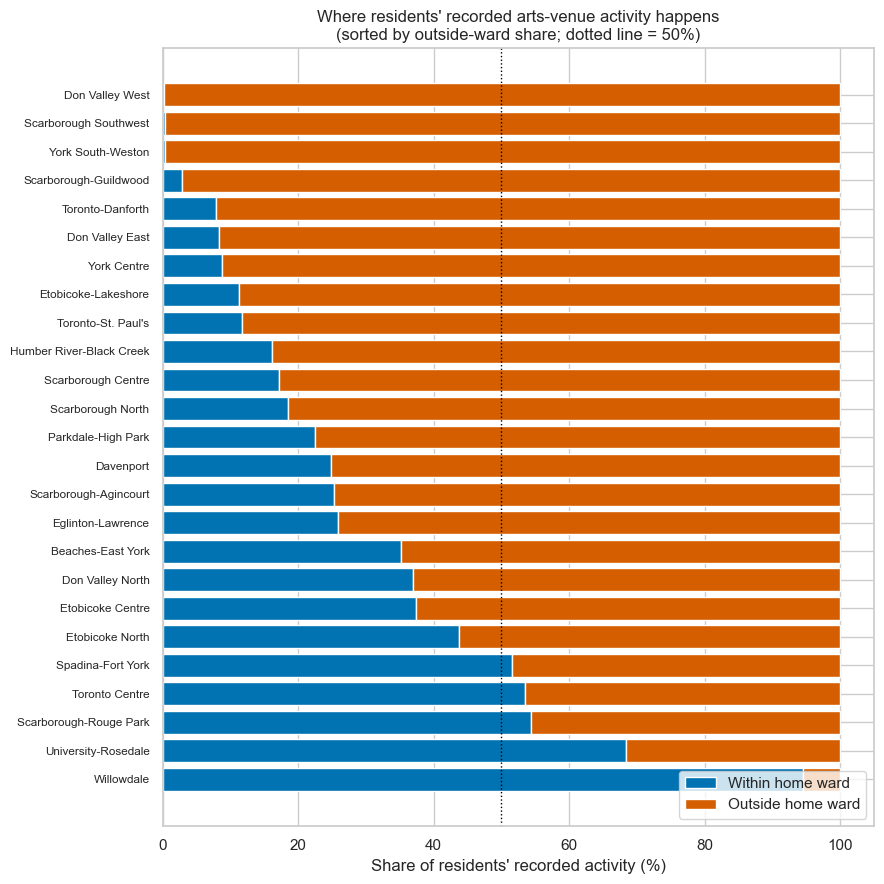

In [13]:
# --- primary visual candidate 1: sorted within/outside stacked bar ---------
plot_df = ward_reach.sort_values("origin_outside_ward_share", ascending=True)
fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(plot_df))
ax.barh(y, plot_df["origin_within_ward_share"] * 100, color=PALETTE[0], label="Within home ward")
ax.barh(y, plot_df["origin_outside_ward_share"] * 100, left=plot_df["origin_within_ward_share"] * 100,
        color=PALETTE[3], label="Outside home ward")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["ward_name"], fontsize=8.5)
ax.axvline(50, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Share of residents' recorded activity (%)")
ax.set_title("Where residents' recorded arts-venue activity happens\n(sorted by outside-ward share; dotted line = 50%)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


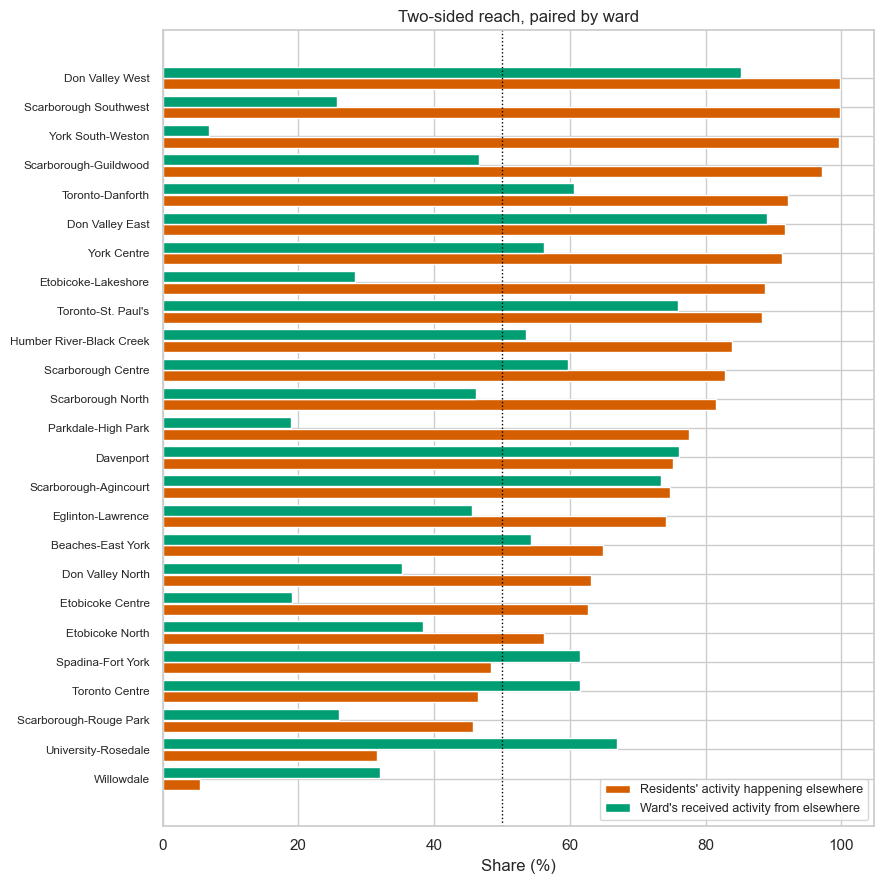

,ward_name,region,n_venues,residents_activity_outside_pct,residents_top_outside_destination,venues_activity_from_outside_pct,venues_top_outside_origin
0,Beaches-East York,Toronto and East York,3,65.00,Toronto Centre,54.00,Toronto-Danforth
1,Davenport,Toronto and East York,9,75.00,Spadina-Fort York,76.00,Spadina-Fort York
2,Don Valley East,North York,1,92.00,Spadina-Fort York,89.00,Humber River-Black Creek
3,Don Valley North,North York,1,63.00,Willowdale,35.00,Don Valley East
4,Don Valley West,North York,2,100.00,Willowdale,85.00,Scarborough-Agincourt
5,Eglinton-Lawrence,Etobicoke York,1,74.00,Willowdale,46.00,York South-Weston
6,Etobicoke Centre,Etobicoke York,3,63.00,University-Rosedale,19.00,Don Valley North
7,Etobicoke North,Etobicoke York,1,56.00,Willowdale,38.00,Humber River-Black Creek
8,Etobicoke-Lakeshore,Etobicoke York,4,89.00,Spadina-Fort York,28.00,Etobicoke Centre
9,Humber River-Black Creek,Etobicoke York,2,84.00,Don Valley East,54.00,Beaches-East York


In [14]:
# --- primary visual candidate 2: paired "residents leaving" vs. "outsiders entering" ---
plot_df2 = ward_reach.sort_values("origin_outside_ward_share", ascending=True)
fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(plot_df2))
ax.barh(y - 0.2, plot_df2["origin_outside_ward_share"] * 100, height=0.38, color=PALETTE[3], label="Residents' activity happening elsewhere")
ax.barh(y + 0.2, plot_df2["dest_outside_ward_share"] * 100, height=0.38, color=PALETTE[2], label="Ward's received activity from elsewhere")
ax.set_yticks(y)
ax.set_yticklabels(plot_df2["ward_name"], fontsize=8.5)
ax.axvline(50, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Share (%)")
ax.set_title("Two-sided reach, paired by ward")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# --- councillor-oriented compact table --------------------------------------
councillor_table = ward_reach[[
    "ward_name", "region", "n_venues", "origin_outside_ward_share", "leading_outside_dest_ward",
    "dest_outside_ward_share", "leading_outside_origin_ward",
]].rename(columns={
    "origin_outside_ward_share": "residents_activity_outside_pct",
    "leading_outside_dest_ward": "residents_top_outside_destination",
    "dest_outside_ward_share": "venues_activity_from_outside_pct",
    "leading_outside_origin_ward": "venues_top_outside_origin",
})
councillor_table["residents_activity_outside_pct"] = (councillor_table["residents_activity_outside_pct"] * 100).round(0)
councillor_table["venues_activity_from_outside_pct"] = (councillor_table["venues_activity_from_outside_pct"] * 100).round(0)
councillor_table.sort_values("ward_name")


**Findings.**
- Citywide, activity-weighted: **52.0%** of normalized ward-mapped activity happens outside residents' home ward; excluding Meridian Arts Centre, this rises to **60.8%**.
- **20 of 25 wards** send a majority (>50%) of their residents' activity outside their own ward; excluding Meridian, **19 of 25** do (Willowdale is the one ward that flips, because Meridian is one of only two venues in Willowdale and dominates its within-ward total).
- The **unweighted median ward** sends **77.6%** of residents' activity elsewhere — much higher than the 52.0% activity-weighted figure. This gap exists because a few large-volume wards (Willowdale via Meridian, University-Rosedale, Toronto Centre) have unusually high within-ward shares and carry outsized weight in the activity-weighted number; most individual wards, weighted equally, look considerably more outward-looking than the citywide average suggests.
- Willowdale and University-Rosedale are the most self-contained wards (6% and 32% outside); Don Valley West, Scarborough Southwest and York South-Weston are the most outward-looking (~100%, though each has only 1–2 included venues, so this reflects a thin local sample as much as a genuine behavioural pattern).
- Destination **volume and destination *reach* are only weakly related** (Spearman ρ = 0.19): Willowdale and University-Rosedale are both high-volume *and* high-reach, but several small-volume wards (Don Valley West, York Centre) also show high effective-N of origin wards, because a handful of visits are spread thinly rather than concentrated — a reminder to read effective-N together with the total, not alone.

**Takeaway.** Both the "most activity crosses ward lines" framing and the "most wards see most of their residents' activity leave" framing are true and mutually reinforcing, but they are different claims with different numbers — the story should state which one is being used at each point, and lead with whichever a specific councillor's own ward supports.

**Story implication — which visual should lead.** The **sorted within/outside stacked bar** (first figure in this section) is the strongest primary visual: one bar per ward, instantly showing "your ward is majority outside" for 20 of 25 councillors, with the 50% line doing the argumentative work. The **paired leaving/entering bar** is a strong secondary visual for wards where councillors want to see the two-way relationship. The **origin/destination quadrant** (Section 2) is best kept as a secondary, discussion visual. The **councillor-oriented compact table** above is the right reference appendix, not a headline graphic.


## 4. Toronto as a regional network

We classify all 25 wards into four regions using the City of Toronto's four **Community Council areas** — the current, official governance grouping (not an ad hoc geographic guess). This gives us a transparent primary "downtown/core" definition (the **Toronto and East York** area, 8 wards) with a natural, citable alternative to test sensitivity: the **narrower old-City-of-Toronto footprint** (7 wards, excluding Beaches-East York, which is former East York).

We deliberately do **not** treat "suburb" as one bucket: Etobicoke York, North York and Scarborough are kept separate throughout, so we can see whether suburb-to-suburb activity is a single citywide pattern or specific to particular regions.


In [15]:
def region_of(ward, downtown_wards):
    if ward in downtown_wards:
        return "Downtown/core"
    return WARD_REGION[ward]


def classify_flow(origin, dest, downtown_wards):
    if origin == dest:
        return "within same ward"
    o_region, d_region = region_of(origin, downtown_wards), region_of(dest, downtown_wards)
    if o_region == "Downtown/core" and d_region == "Downtown/core":
        return "within downtown/core"
    if o_region == "Downtown/core" and d_region != "Downtown/core":
        return "downtown to suburb"
    if o_region != "Downtown/core" and d_region == "Downtown/core":
        return "suburb to downtown"
    if o_region == d_region:
        return "within same suburban region"
    return "between different suburban regions"


def flow_breakdown(downtown_wards, label):
    outside = ward_to_ward_activity.loc[~ward_to_ward_activity["same_ward"]].copy()
    outside["flow_type"] = outside.apply(lambda r: classify_flow(r["origin_ward"], r["dest_ward"], downtown_wards), axis=1)
    totals = outside.groupby("flow_type")["normalized_raw_stop_count_by_ward"].sum()
    shares = (totals / totals.sum() * 100).round(1).sort_values(ascending=False)
    print(f"--- outside-ward flow composition, downtown definition = {label} ---")
    print(shares.to_string())
    suburb_to_suburb = shares.get("within same suburban region", 0) + shares.get("between different suburban regions", 0)
    print(f"total suburb-to-suburb (same + different suburban regions): {suburb_to_suburb:.1f}%")
    return shares


shares_broad = flow_breakdown(DOWNTOWN_CORE_WARDS_BROAD, "broad (Toronto and East York, 8 wards)")
print()
shares_narrow = flow_breakdown(DOWNTOWN_CORE_WARDS_NARROW, "narrow (old City of Toronto, 7 wards, excl. Beaches-East York)")


--- outside-ward flow composition, downtown definition = broad (Toronto and East York, 8 wards) ---
flow_type
within downtown/core                 41.90
suburb to downtown                   28.20
between different suburban regions   13.80
within same suburban region          10.30
downtown to suburb                    5.80
total suburb-to-suburb (same + different suburban regions): 24.1%

--- outside-ward flow composition, downtown definition = narrow (old City of Toronto, 7 wards, excl. Beaches-East York) ---
flow_type
within downtown/core                 37.70
suburb to downtown                   29.90
between different suburban regions   16.00
within same suburban region          10.30
downtown to suburb                    6.20
total suburb-to-suburb (same + different suburban regions): 26.3%


In [16]:
# --- conditional stat: OF suburban residents' outside-ward activity, how much stays suburban? ---
def suburban_conditional_share(downtown_wards, label):
    outside = ward_to_ward_activity.loc[~ward_to_ward_activity["same_ward"]].copy()
    outside["origin_region"] = outside["origin_ward"].apply(lambda w: region_of(w, downtown_wards))
    outside["dest_region"] = outside["dest_ward"].apply(lambda w: region_of(w, downtown_wards))
    suburban_origin = outside[outside["origin_region"] != "Downtown/core"]
    total = suburban_origin["normalized_raw_stop_count_by_ward"].sum()
    to_suburb = suburban_origin.loc[suburban_origin["dest_region"] != "Downtown/core", "normalized_raw_stop_count_by_ward"].sum()
    share = to_suburb / total
    print(f"[{label}] of SUBURBAN residents' outside-ward activity, share going to another suburban ward (not downtown): {share:.1%}")
    return share


_ = suburban_conditional_share(DOWNTOWN_CORE_WARDS_BROAD, "broad downtown definition")
_ = suburban_conditional_share(DOWNTOWN_CORE_WARDS_NARROW, "narrow downtown definition")


[broad downtown definition] of SUBURBAN residents' outside-ward activity, share going to another suburban ward (not downtown): 46.2%
[narrow downtown definition] of SUBURBAN residents' outside-ward activity, share going to another suburban ward (not downtown): 46.8%


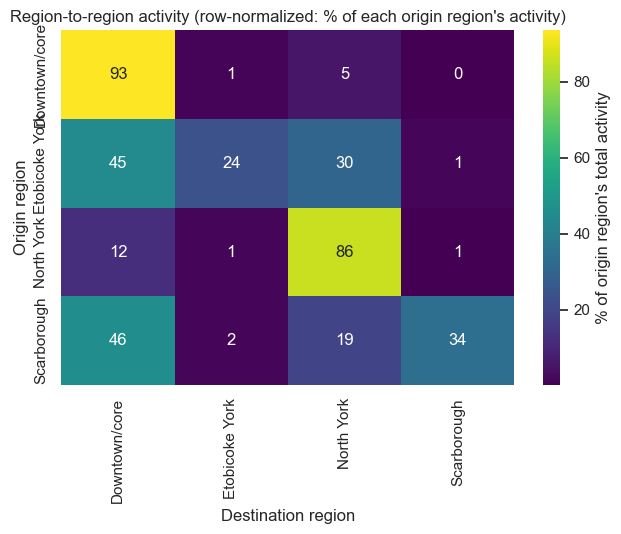

Top cross-region suburb-to-suburb ward pairs by two-way activity:


,ward_a,ward_b,a_to_b,b_to_a,two_way_total,reciprocity
241,Willowdale,York Centre,49.73,"1,347.73","1,397.46",0.04
47,Don Valley East,Humber River-Black Creek,10.09,893.01,903.10,0.01
109,Eglinton-Lawrence,Willowdale,807.14,19.56,826.70,0.02
163,Humber River-Black Creek,Willowdale,599.19,86.96,686.15,0.15
186,Scarborough Centre,Willowdale,380.38,11.25,391.62,0.03
207,Scarborough-Agincourt,Willowdale,331.87,4.71,336.57,0.01
139,Etobicoke North,Willowdale,328.42,6.09,334.51,0.02
195,Scarborough North,Willowdale,270.92,3.99,274.90,0.01


In [17]:
# --- region-to-region flow matrix (using the broad downtown definition) ----
region_map_broad = {w: region_of(w, DOWNTOWN_CORE_WARDS_BROAD) for w in WARD_REGION}
region_flow = ward_to_ward_activity.copy()
region_flow["origin_region"] = region_flow["origin_ward"].map(region_map_broad)
region_flow["dest_region"] = region_flow["dest_ward"].map(region_map_broad)
region_matrix = region_flow.groupby(["origin_region", "dest_region"])["normalized_raw_stop_count_by_ward"].sum().unstack()
region_order = ["Downtown/core", "Etobicoke York", "North York", "Scarborough"]
region_matrix = region_matrix.reindex(index=region_order, columns=region_order)
region_matrix_pct = region_matrix.div(region_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(region_matrix_pct, annot=True, fmt=".0f", cmap="viridis", cbar_kws={"label": "% of origin region's total activity"}, ax=ax)
ax.set_xlabel("Destination region")
ax.set_ylabel("Origin region")
ax.set_title("Region-to-region activity (row-normalized: % of each origin region's activity)")
plt.tight_layout()
plt.show()

# --- ranked bilateral ward pairs across different suburban regions ---------
cross_suburb_pairs = reciprocal_pairs[
    reciprocal_pairs["ward_a"].map(WARD_REGION).isin(SUBURBAN_REGIONS)
    & reciprocal_pairs["ward_b"].map(WARD_REGION).isin(SUBURBAN_REGIONS)
    & (reciprocal_pairs["ward_a"].map(WARD_REGION) != reciprocal_pairs["ward_b"].map(WARD_REGION))
]
print("Top cross-region suburb-to-suburb ward pairs by two-way activity:")
cross_suburb_pairs.head(8)


**Findings.**
- Of all outside-ward activity citywide, **within-downtown/core** movement is the single largest slice (41.9% broad / 37.7% narrow definition), followed by **suburb-to-downtown** (28.2% / 29.9%). Combined suburb-to-suburb movement (same suburban region + between different suburban regions) is **24.1% (broad) / 26.3% (narrow)** of *all* outside-ward activity.
- The more relevant conditional statistic — **of suburban residents' own outside-ward activity specifically**, how much goes to another suburban ward rather than downtown — is **46.2% (broad) / 46.8% (narrow) definition**. This is in the same range as, but somewhat higher than, the ~43.1% starting estimate; the two downtown definitions barely move it (±0.6 pp), so this finding is **not an artifact of where we draw the downtown boundary**.
- The region-to-region heatmap shows this is not one uniform pattern: **North York's** cross-suburban pull is dominated almost entirely by Willowdale/Meridian drawing in residents from Etobicoke York and Scarborough wards with near-zero reciprocity (reciprocity 0.01–0.15) — i.e., these look more like "one regional anchor venue draws widely" than a genuine two-way suburban network.

**Takeaway.** The suburb-to-suburb claim is real and robust to the downtown-boundary definition, but its current strongest evidence is concentrated in flows *into* Willowdale (via Meridian), which is a single-venue effect, not yet a broad multi-venue regional network. The Scarborough case study (Section 5) is needed to see whether a more genuinely distributed multi-venue suburban network exists elsewhere.

**Story implication.** Report the **conditional 46%** figure (suburban-outside-ward-activity that stays suburban) as the headline "suburb-to-suburb" number, explicitly labelled as conditional on already having left the home ward — not as a share of all activity. Flag the low-reciprocity, Willowdale-dominated composition as a caveat rather than suppressing it.


## 5. Scarborough as the main regional case study

We now examine all six Scarborough wards together — Scarborough Southwest, Scarborough Centre, Scarborough-Agincourt, Scarborough North, Scarborough-Guildwood, and Scarborough-Rouge Park — not just Scarborough North, to see whether a genuine multi-ward network exists (unlike the single-venue-driven Willowdale pattern found in Section 4).


In [18]:
# --- per-Scarborough-ward destination composition --------------------------
def scarborough_composition_bucket(dest_ward, origin_ward):
    if dest_ward == origin_ward:
        return "same ward"
    if dest_ward in SCARBOROUGH_WARDS:
        return "other Scarborough"
    if dest_ward in ("Willowdale",) or WARD_REGION[dest_ward] == "North York":
        return "North York / Willowdale"
    if dest_ward in DOWNTOWN_CORE_WARDS_BROAD:
        return "downtown"
    return "elsewhere in Toronto"


scarb_flow = ward_to_ward_activity[ward_to_ward_activity["origin_ward"].isin(SCARBOROUGH_WARDS)].copy()
scarb_flow["bucket"] = scarb_flow.apply(lambda r: scarborough_composition_bucket(r["dest_ward"], r["origin_ward"]), axis=1)
scarb_composition = scarb_flow.groupby(["origin_ward", "bucket"])["normalized_raw_stop_count_by_ward"].sum().unstack(fill_value=0)
scarb_composition_pct = scarb_composition.div(scarb_composition.sum(axis=1), axis=0) * 100
bucket_order = ["same ward", "other Scarborough", "North York / Willowdale", "downtown", "elsewhere in Toronto"]
scarb_composition_pct = scarb_composition_pct.reindex(columns=bucket_order).reindex(SCARBOROUGH_WARDS)
scarb_composition_pct.round(1)


bucket,same ward,other Scarborough,North York / Willowdale,downtown,elsewhere in Toronto
origin_ward,,,,,
Scarborough Southwest,0.30,7.80,10.90,79.60,1.40
Scarborough Centre,17.10,11.60,19.40,50.20,1.70
Scarborough-Agincourt,25.30,6.40,33.60,32.20,2.50
Scarborough North,18.40,38.30,22.10,20.10,1.10
Scarborough-Guildwood,2.80,25.60,22.80,45.60,3.20
Scarborough-Rouge Park,54.40,5.90,16.10,22.80,0.80


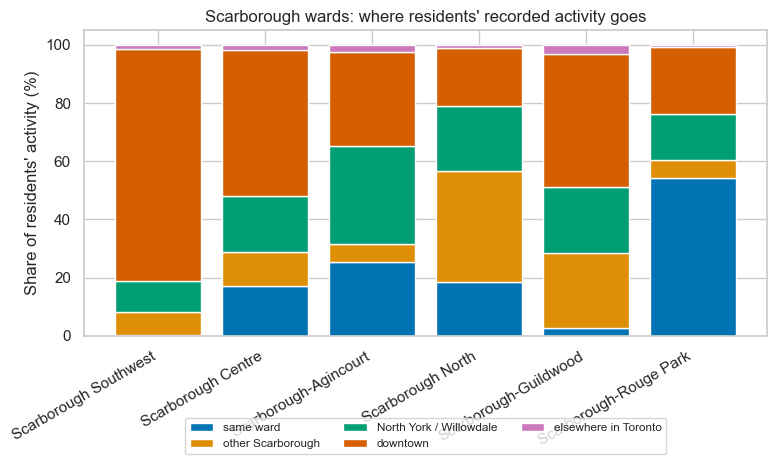

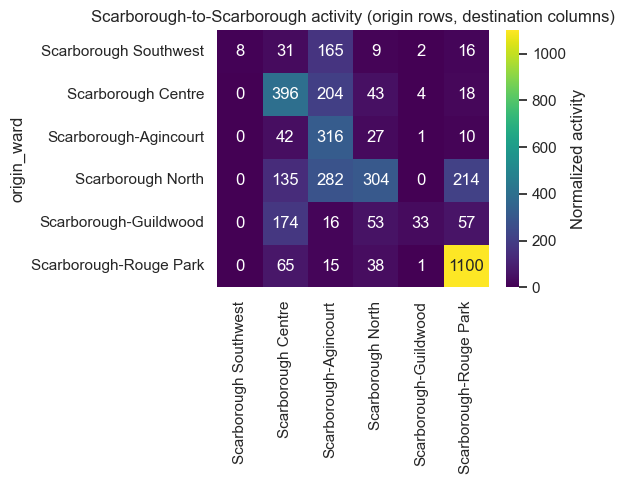

Strongest Scarborough-to-Scarborough reciprocal pairs:


,ward_a,ward_b,a_to_b,b_to_a,two_way_total,reciprocity
188,Scarborough North,Scarborough-Agincourt,282.05,26.54,308.59,0.09
189,Scarborough North,Scarborough-Rouge Park,213.75,38.48,252.24,0.18
178,Scarborough Centre,Scarborough-Agincourt,203.52,41.85,245.37,0.21
177,Scarborough Centre,Scarborough North,43.45,134.95,178.40,0.32
179,Scarborough Centre,Scarborough-Guildwood,3.55,173.63,177.18,0.02
197,Scarborough Southwest,Scarborough-Agincourt,164.63,0.20,164.83,0.00
180,Scarborough Centre,Scarborough-Rouge Park,17.78,65.24,83.02,0.27
209,Scarborough-Guildwood,Scarborough-Rouge Park,56.96,0.75,57.71,0.01
202,Scarborough-Agincourt,Scarborough-Rouge Park,9.86,15.15,25.01,0.65
201,Scarborough-Agincourt,Scarborough-Guildwood,1.31,16.04,17.35,0.08



Included venues located in Scarborough wards:


,venue_id,venue_name,dest_ward,n_venues_in_ward
458,19,Cedar Ridge Creative Centre,Scarborough-Guildwood,3
483,20,Clark Centre for the Arts,Scarborough-Guildwood,3
1156,48,Malvern Library,Scarborough-Rouge Park,1
1357,56,P.C. Ho Theatre,Scarborough North,2
1580,65,Bluffs Gallery,Scarborough Southwest,1
2084,85,Scarborough Civic Centre Library,Scarborough Centre,2
2335,96,Agincourt Toronto Public Library,Scarborough-Agincourt,1
2359,97,Birkdale Community Centre,Scarborough Centre,2
2383,98,Cedarbrook Community Centre,Scarborough-Guildwood,3
2407,99,Woodside Square Cinemas,Scarborough North,2


In [19]:
# --- stacked bar: each Scarborough ward's destination composition ----------
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(scarb_composition_pct))
colors = sns.color_palette("colorblind", n_colors=len(bucket_order))
for color, bucket in zip(colors, bucket_order):
    vals = scarb_composition_pct[bucket].values
    ax.bar(scarb_composition_pct.index, vals, bottom=bottom, label=bucket, color=color)
    bottom += vals
ax.set_ylabel("Share of residents' activity (%)")
ax.set_title("Scarborough wards: where residents' recorded activity goes")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- Scarborough-only origin/destination matrix + strongest connections ----
scarb_matrix = ward_to_ward_matrix.loc[SCARBOROUGH_WARDS, SCARBOROUGH_WARDS]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(scarb_matrix, annot=True, fmt=".0f", cmap="viridis", ax=ax, cbar_kws={"label": "Normalized activity"})
ax.set_title("Scarborough-to-Scarborough activity (origin rows, destination columns)")
plt.tight_layout()
plt.show()

scarb_pairs = reciprocal_pairs[reciprocal_pairs["ward_a"].isin(SCARBOROUGH_WARDS) & reciprocal_pairs["ward_b"].isin(SCARBOROUGH_WARDS)]
print("Strongest Scarborough-to-Scarborough reciprocal pairs:")
display(scarb_pairs.sort_values("two_way_total", ascending=False))

# principal venues underlying the strongest Scarborough-internal connections
scarb_dest_venues = venue_to_dest_ward[venue_to_dest_ward["dest_ward"].isin(SCARBOROUGH_WARDS)]
print("\nIncluded venues located in Scarborough wards:")
display(scarb_dest_venues.merge(venues_per_ward.rename("n_venues_in_ward"), left_on="dest_ward", right_index=True))


In [20]:
# --- is the Scarborough network dependent on a single dominant venue? ------
scarb_venue_activity = ward_to_venue_activity[ward_to_venue_activity["dest_ward"].isin(SCARBOROUGH_WARDS)]
scarb_venue_totals = scarb_venue_activity.groupby("venue_name")["normalized_raw_stop_count_by_ward"].sum().sort_values(ascending=False)
top_scarb_venue = scarb_venue_totals.index[0]
top_scarb_venue_id = venue_meta.loc[venue_meta["venue_name"] == top_scarb_venue, "venue_id"].iloc[0]
top_scarb_share = scarb_venue_totals.iloc[0] / scarb_venue_totals.sum()
print(f"Largest included venue among Scarborough destinations: {top_scarb_venue} ({top_scarb_share:.1%} of all Scarborough-destination activity)")

# recompute the Scarborough-to-Scarborough share of Scarborough-destined activity, excluding the top venue entirely
scarb_venue_activity_ex_top = scarb_venue_activity[scarb_venue_activity["venue_id"] != top_scarb_venue_id]
same_scarb_ex_top = scarb_venue_activity_ex_top.groupby(["origin_ward", "dest_ward"], as_index=False)["normalized_raw_stop_count_by_ward"].sum()
same_scarb_ex_top = same_scarb_ex_top[same_scarb_ex_top["origin_ward"].isin(SCARBOROUGH_WARDS)]
other_scarb_ex_top = same_scarb_ex_top.loc[same_scarb_ex_top["origin_ward"] != same_scarb_ex_top["dest_ward"], "normalized_raw_stop_count_by_ward"].sum()
total_scarb_dest_ex_top = same_scarb_ex_top["normalized_raw_stop_count_by_ward"].sum()
if total_scarb_dest_ex_top > 0:
    print(f"Scarborough-to-Scarborough share of Scarborough-destined activity, excluding {top_scarb_venue}: "
          f"{other_scarb_ex_top / total_scarb_dest_ex_top:.1%}")
else:
    print(f"No Scarborough-destined activity remains after excluding {top_scarb_venue} (it is the only included venue in its ward).")

# regional-node check: which Scarborough ward receives the most FROM other Scarborough wards?
scarb_internal = scarb_flow[(scarb_flow["dest_ward"].isin(SCARBOROUGH_WARDS)) & (scarb_flow["origin_ward"] != scarb_flow["dest_ward"])]
node_scores = scarb_internal.groupby("dest_ward")["normalized_raw_stop_count_by_ward"].sum().sort_values(ascending=False)
print("\nScarborough wards ranked by activity received FROM other Scarborough wards (candidate 'regional node'):")
print(node_scores.to_string())


Largest included venue among Scarborough destinations: Malvern Library (34.6% of all Scarborough-destination activity)
Scarborough-to-Scarborough share of Scarborough-destined activity, excluding Malvern Library: 55.3%

Scarborough wards ranked by activity received FROM other Scarborough wards (candidate 'regional node'):
dest_ward
Scarborough-Agincourt    681.40
Scarborough Centre       447.07
Scarborough-Rouge Park   314.30
Scarborough North        169.96
Scarborough-Guildwood      7.44
Scarborough Southwest      0.20


**Findings.**
- The six Scarborough wards do **not** behave as one homogeneous "suburb": **Scarborough North** sends more of its residents' activity to *other Scarborough wards* (38.3%) than to North York/Willowdale (22.1%) or downtown (20.1%) — a genuinely distinct pattern from, say, Scarborough Southwest, which is 79.6% downtown-bound.
- **Scarborough-Agincourt** is the clearest candidate **regional node**: it receives more activity from other Scarborough wards (681 normalized units) than any other Scarborough ward, more than double the next-highest (Scarborough Centre, 447). Scarborough North → Scarborough-Agincourt is the single strongest Scarborough-internal connection (283 units), though with low reciprocity (0.09) — Agincourt draws from its neighbours more than it sends back.
- The Scarborough-internal network is **not** an artifact of one dominant venue: Malvern Library alone is 34.6% of all Scarborough-destination activity, but *excluding it entirely*, the remaining Scarborough-destined activity is still **55.3%** sourced from other Scarborough wards — the network survives removing the single largest venue, unlike the Willowdale/Meridian pattern in Section 4.
- The principal venues underlying these connections are civic/public infrastructure, not standalone arts venues: **Scarborough Civic Centre Library** and **Birkdale Community Centre** (Scarborough Centre), **Agincourt Toronto Public Library** (Scarborough-Agincourt), and **P.C. Ho Theatre** / **Woodside Square Cinemas** (Scarborough North) — public libraries and community centres carry much of this connective activity.

**Takeaway.** Scarborough is not one network but at least two distinguishable sub-patterns: a **downtown-oriented southwest** (Scarborough Southwest, and to a lesser extent Scarborough-Guildwood) and an **internally-connected north/east cluster** (Scarborough North, Centre, Agincourt, Rouge Park) that routes meaningfully through Scarborough-Agincourt as a hub.

**Story implication.** The interpretation *"Scarborough residents do not participate in culture only within their own wards or by travelling downtown; they use a wider eastern and northern network of venues, meaning cultural investment in one suburban ward can benefit residents across several neighbouring wards"* is **well supported for Scarborough North, Centre, Agincourt and Rouge Park specifically**, and should be scoped to those four wards rather than stated for "Scarborough" as a whole — Scarborough Southwest is a counter-example that the story should not paper over.


## 6. Travel distance and transportation context

`venues_homes.csv` gives, for every (home geohash6 cell, venue) pair, the normalized activity from that home area at the `all` time period. We decode each geohash6 cell to its centre point and compute the **straight-line (great-circle) distance** to each venue, weighted by `normalized_raw_stop_count`.

**This is explicitly a straight-line home-area-to-venue distance** — not a travel route, not a travel time, and not an exact home address (a geohash6 cell is roughly 1.2km x 0.6km at Toronto's latitude, so it describes a home *area*, not a household).


In [21]:
import pygeohash as pgh

venues_homes = pd.read_csv(VENUES_HOMES_CSV)
venues_homes = venues_homes[venues_homes["time_period"] == TIME_PERIOD].copy()
print(f"venues_homes (time_period=all): {venues_homes.shape}")

unique_geohashes = venues_homes["home_geohash6"].unique()
print(f"unique home geohash6 cells: {len(unique_geohashes)}")

geohash_coords = pd.DataFrame({"home_geohash6": unique_geohashes})
decoded = [pgh.decode(g) for g in tqdm(unique_geohashes, desc="decoding geohash6 cells")]
geohash_coords["home_lat"] = [d[0] for d in decoded]
geohash_coords["home_lon"] = [d[1] for d in decoded]

# --- spatial join: home geohash6 centre -> ward (reusing the point-in-polygon method from Section 1) --
geohash_points = gpd.GeoDataFrame(
    geohash_coords, geometry=gpd.points_from_xy(geohash_coords["home_lon"], geohash_coords["home_lat"]), crs="EPSG:4326",
)
geohash6_to_ward = gpd.sjoin(geohash_points, wards_gdf[["ward_name", "geometry"]], predicate="within")[
    ["home_geohash6", "home_lat", "home_lon", "ward_name"]
].rename(columns={"ward_name": "origin_ward"})
coverage = geohash6_to_ward["home_geohash6"].nunique() / len(unique_geohashes)
print(f"home geohash6 cells matched to a ward by spatial join: {geohash6_to_ward.shape[0]} / {len(unique_geohashes)} ({coverage:.1%})")


venues_homes (time_period=all): (14745, 10)
unique home geohash6 cells: 1187


decoding geohash6 cells:   0%|          | 0/1187 [00:00<?, ?it/s]

home geohash6 cells matched to a ward by spatial join: 1122 / 1187 (94.5%)


In [22]:
# --- project home cells and venues into the metric UTM CRS, compute straight-line distance --
geohash_gdf_proj = geohash_points.set_geometry(gpd.points_from_xy(geohash_points["home_lon"], geohash_points["home_lat"]), crs="EPSG:4326").to_crs(UTM_CRS)
geohash_coords["easting"] = geohash_gdf_proj.geometry.x
geohash_coords["northing"] = geohash_gdf_proj.geometry.y

venue_points_proj = venue_points.to_crs(UTM_CRS)
venue_xy = pd.DataFrame({"venue_id": venue_points["venue_id"].values,
                          "venue_easting": venue_points_proj.geometry.x.values,
                          "venue_northing": venue_points_proj.geometry.y.values})

homes_dist = venues_homes.merge(geohash_coords[["home_geohash6", "easting", "northing"]], on="home_geohash6", how="left")
homes_dist = homes_dist.merge(venue_xy, on="venue_id", how="left")
homes_dist = homes_dist.merge(geohash6_to_ward[["home_geohash6", "origin_ward"]], on="home_geohash6", how="left")
homes_dist = homes_dist.merge(venue_to_dest_ward[["venue_id", "dest_ward"]], on="venue_id", how="left")

homes_dist["distance_km"] = np.hypot(homes_dist["easting"] - homes_dist["venue_easting"],
                                       homes_dist["northing"] - homes_dist["venue_northing"]) / 1000
n_unmatched = homes_dist["origin_ward"].isna().sum()
print(f"rows with no ward-matched home cell (excluded from ward-level distance summaries): {n_unmatched} / {len(homes_dist)}")
homes_dist_matched = homes_dist.dropna(subset=["origin_ward", "distance_km"])


def weighted_quantiles(df, value_col, weight_col, qs=(0.25, 0.5, 0.75)):
    d = df.sort_values(value_col)
    cum_w = d[weight_col].cumsum() / d[weight_col].sum()
    return {q: float(np.interp(q, cum_w, d[value_col])) for q in qs}


overall_q = weighted_quantiles(homes_dist_matched, "distance_km", "normalized_raw_stop_count")
print(f"\ncitywide normalized-activity-weighted distance distribution (km): "
      f"P25={overall_q[0.25]:.1f}, median={overall_q[0.5]:.1f}, P75={overall_q[0.75]:.1f}")


rows with no ward-matched home cell (excluded from ward-level distance summaries): 291 / 14745

citywide normalized-activity-weighted distance distribution (km): P25=0.3, median=1.5, P75=6.6


In [23]:
# --- distance bands, weighted by normalized activity -----------------------
def distance_band(km):
    if km < 1:
        return "<1km"
    if km < 3:
        return "1-3km"
    if km < 10:
        return "3-10km"
    return "10km+"


homes_dist_matched = homes_dist_matched.copy()
homes_dist_matched["distance_band"] = homes_dist_matched["distance_km"].apply(distance_band)
homes_dist_matched["same_ward"] = homes_dist_matched["origin_ward"] == homes_dist_matched["dest_ward"]

band_order = ["<1km", "1-3km", "3-10km", "10km+"]
band_weighted = homes_dist_matched.groupby("distance_band")["normalized_raw_stop_count"].sum()
band_weighted_pct = (band_weighted / band_weighted.sum() * 100).reindex(band_order)
print("Citywide activity-weighted distance-band distribution:")
print(band_weighted_pct.round(1).to_string())

# same-ward vs. cross-ward
for flag, label in [(True, "same-ward"), (False, "cross-ward")]:
    sub = homes_dist_matched[homes_dist_matched["same_ward"] == flag]
    q = weighted_quantiles(sub, "distance_km", "normalized_raw_stop_count")
    print(f"\n{label} activity: weighted median distance = {q[0.5]:.1f} km (P25={q[0.25]:.1f}, P75={q[0.75]:.1f})")

# suburb-to-suburb vs. suburb-to-downtown
homes_dist_matched["origin_region"] = homes_dist_matched["origin_ward"].apply(lambda w: region_of(w, DOWNTOWN_CORE_WARDS_BROAD))
homes_dist_matched["dest_region"] = homes_dist_matched["dest_ward"].apply(lambda w: region_of(w, DOWNTOWN_CORE_WARDS_BROAD))
suburb_to_suburb = homes_dist_matched[(homes_dist_matched["origin_region"] != "Downtown/core") & (homes_dist_matched["dest_region"] != "Downtown/core") & (~homes_dist_matched["same_ward"])]
suburb_to_downtown = homes_dist_matched[(homes_dist_matched["origin_region"] != "Downtown/core") & (homes_dist_matched["dest_region"] == "Downtown/core")]
for sub, label in [(suburb_to_suburb, "suburb-to-suburb"), (suburb_to_downtown, "suburb-to-downtown")]:
    q = weighted_quantiles(sub, "distance_km", "normalized_raw_stop_count")
    print(f"{label} activity: weighted median distance = {q[0.5]:.1f} km (P25={q[0.25]:.1f}, P75={q[0.75]:.1f}), n cells={sub['home_geohash6'].nunique()}")

# Scarborough-specific flow types
scarb_dist = homes_dist_matched[homes_dist_matched["origin_ward"].isin(SCARBOROUGH_WARDS)].copy()
scarb_dist["flow_bucket"] = scarb_dist.apply(lambda r: scarborough_composition_bucket(r["dest_ward"], r["origin_ward"]), axis=1)
print("\nScarborough-origin weighted median distance by destination bucket:")
for bucket, sub in scarb_dist.groupby("flow_bucket"):
    q = weighted_quantiles(sub, "distance_km", "normalized_raw_stop_count")
    print(f"  {bucket}: median={q[0.5]:.1f} km, n cells={sub['home_geohash6'].nunique()}")


Citywide activity-weighted distance-band distribution:
distance_band
<1km     43.50
1-3km    19.10
3-10km   22.20
10km+    15.20

same-ward activity: weighted median distance = 0.3 km (P25=0.1, P75=0.9)



cross-ward activity: weighted median distance = 6.2 km (P25=2.4, P75=11.0)


suburb-to-suburb activity: weighted median distance = 6.6 km (P25=3.5, P75=11.9), n cells=874


suburb-to-downtown activity: weighted median distance = 11.3 km (P25=8.5, P75=14.0), n cells=877

Scarborough-origin weighted median distance by destination bucket:
  North York / Willowdale: median=12.5 km, n cells=301
  downtown: median=13.5 km, n cells=298
  elsewhere in Toronto: median=20.0 km, n cells=77
  other Scarborough: median=4.3 km, n cells=208
  same ward: median=0.9 km, n cells=167


In [24]:
# --- census transit/commute/density variables --------------------------------
TRANSPORT_CHARACTERISTICS = {
    2607: "transit_commute_count", 2604: "car_commute_count",
    2611: "commute_universe_count", 2615: "commute_45_59min_count", 2616: "commute_60plus_count",
    6: "population_density",
}
transport_wide = census_long[census_long["CHARACTERISTIC_ID"].isin(TRANSPORT_CHARACTERISTICS)].pivot_table(
    index="ward_name", columns="CHARACTERISTIC_ID", values="C1_COUNT_TOTAL", aggfunc="first"
).rename(columns=TRANSPORT_CHARACTERISTICS)
transport_wide["transit_commute_share"] = transport_wide["transit_commute_count"] / transport_wide["commute_universe_count"]
transport_wide["car_commute_share"] = transport_wide["car_commute_count"] / transport_wide["commute_universe_count"]
transport_wide["long_commute_share"] = (transport_wide["commute_45_59min_count"] + transport_wide["commute_60plus_count"]) / transport_wide["commute_universe_count"]
transport_wide = transport_wide.reset_index()

ward_reach_transport = ward_reach.merge(transport_wide, on="ward_name")
print(f"ward_reach_transport: {ward_reach_transport.shape}")
ward_reach_transport[["ward_name", "transit_commute_share", "car_commute_share", "long_commute_share", "population_density"]].describe().round(2)


ward_reach_transport: (25, 33)


,transit_commute_share,car_commute_share,long_commute_share,population_density
count,25.00,25.00,25.00,25.00
mean,0.26,0.60,0.23,"5,660.96"
std,0.05,0.13,0.04,"3,794.87"
min,0.15,0.29,0.15,"1,920.90"
25%,0.22,0.52,0.20,"3,575.40"
50%,0.27,0.64,0.24,"4,669.60"
75%,0.30,0.68,0.26,"6,531.20"
max,0.35,0.78,0.31,"20,546.50"


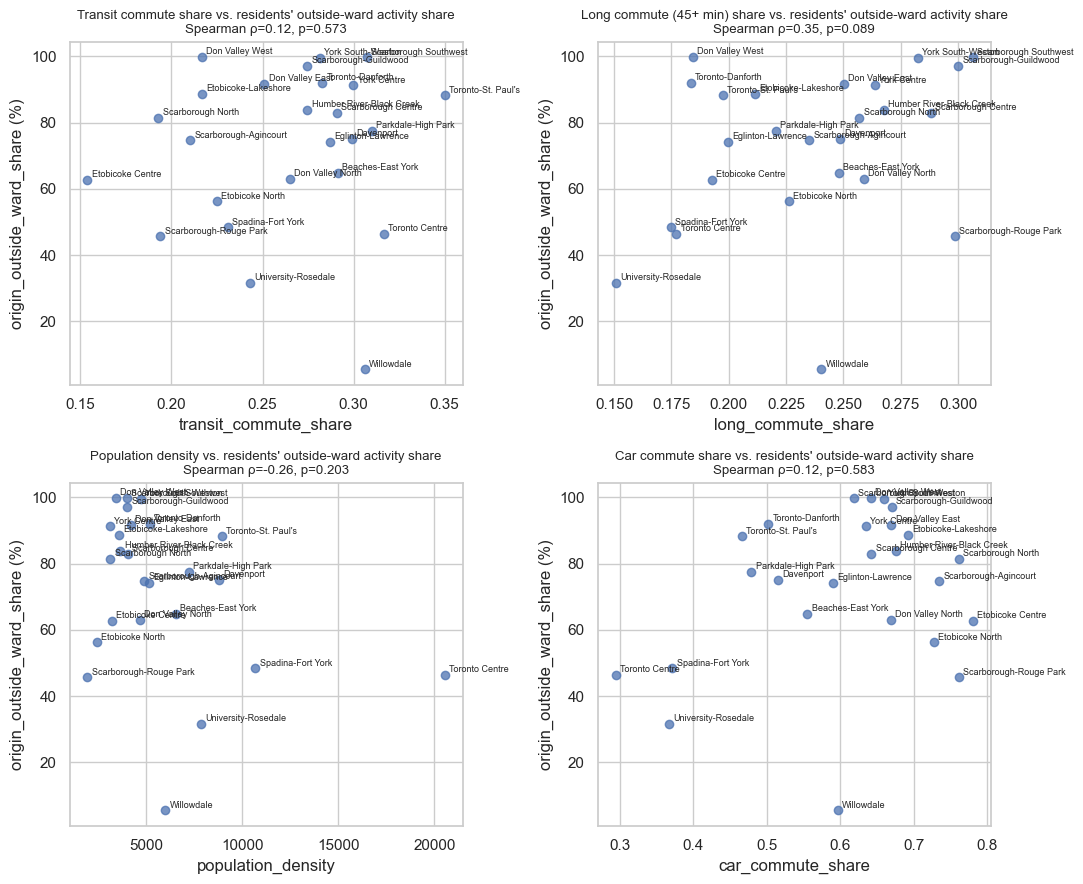

,x,y,spearman_rho,p_value
0,transit_commute_share,origin_outside_ward_share,0.12,0.57
1,long_commute_share,origin_outside_ward_share,0.35,0.09
2,population_density,origin_outside_ward_share,-0.26,0.20
3,car_commute_share,origin_outside_ward_share,0.12,0.58


In [25]:
from scipy.stats import spearmanr

HYPOTHESIS_PAIRS = [
    ("transit_commute_share", "origin_outside_ward_share", "Transit commute share vs. residents' outside-ward activity share"),
    ("long_commute_share", "origin_outside_ward_share", "Long commute (45+ min) share vs. residents' outside-ward activity share"),
    ("population_density", "origin_outside_ward_share", "Population density vs. residents' outside-ward activity share"),
    ("car_commute_share", "origin_outside_ward_share", "Car commute share vs. residents' outside-ward activity share"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
results = []
for ax, (x, y, title) in zip(axes.flat, HYPOTHESIS_PAIRS):
    rho, p = spearmanr(ward_reach_transport[x], ward_reach_transport[y])
    results.append({"x": x, "y": y, "spearman_rho": rho, "p_value": p})
    ax.scatter(ward_reach_transport[x], ward_reach_transport[y] * 100, alpha=0.75)
    for _, row in ward_reach_transport.iterrows():
        ax.annotate(row["ward_name"], (row[x], row[y] * 100), fontsize=6.5, xytext=(3, 2), textcoords="offset points")
    ax.set_title(f"{title}\nSpearman ρ={rho:.2f}, p={p:.3f}", fontsize=9.5)
    ax.set_xlabel(x)
    ax.set_ylabel(f"{y} (%)")
plt.tight_layout()
plt.show()
pd.DataFrame(results)


In [26]:
# --- leave-one-out sensitivity on the strongest correlation above ----------
strongest = pd.DataFrame(results).assign(abs_rho=lambda d: d["spearman_rho"].abs()).sort_values("abs_rho", ascending=False).iloc[0]
x_col, y_col = strongest["x"], strongest["y"]
print(f"Strongest pair: {x_col} vs. {y_col} (full-sample rho={strongest['spearman_rho']:.2f})")

loo_rhos = []
for ward in tqdm(ward_reach_transport["ward_name"], desc="leave-one-out"):
    sub = ward_reach_transport[ward_reach_transport["ward_name"] != ward]
    rho, _ = spearmanr(sub[x_col], sub[y_col])
    loo_rhos.append({"excluded_ward": ward, "rho_excl": rho})
loo_df = pd.DataFrame(loo_rhos).sort_values("rho_excl")
print(f"leave-one-out rho range: [{loo_df['rho_excl'].min():.2f}, {loo_df['rho_excl'].max():.2f}] (full-sample rho={strongest['spearman_rho']:.2f})")
print("\nMost influential wards (largest shift in rho when excluded):")
loo_df["abs_shift"] = (loo_df["rho_excl"] - strongest["spearman_rho"]).abs()
loo_df.sort_values("abs_shift", ascending=False).head(5)


Strongest pair: long_commute_share vs. origin_outside_ward_share (full-sample rho=0.35)


leave-one-out:   0%|          | 0/25 [00:00<?, ?it/s]

leave-one-out rho range: [0.27, 0.46] (full-sample rho=0.35)

Most influential wards (largest shift in rho when excluded):


,excluded_ward,rho_excl,abs_shift
4,Don Valley West,0.46,0.12
16,Scarborough-Rouge Park,0.46,0.11
21,University-Rosedale,0.27,0.07
19,Toronto-Danforth,0.42,0.07
13,Scarborough Southwest,0.28,0.07


**Findings.**
- Weighted distances behave exactly as the cross-ward thesis would predict: **same-ward** activity has a weighted median distance of **0.3 km**; **cross-ward** activity, **6.2 km**. **Suburb-to-suburb** activity (median 6.6 km) is meaningfully *shorter* than **suburb-to-downtown** activity (median 11.3 km) — cross-ward participation in the suburbs is not automatically a long trip.
- Within Scarborough specifically, trips to **other Scarborough wards** have a weighted median distance of **4.3 km**, versus **12.5 km** to North York/Willowdale and **13.5 km** to downtown — the regional-network pattern found in Section 5 corresponds to genuinely shorter straight-line distances, not just a data artifact.
- The hypothesis tests against census transportation variables are **weak and not statistically significant**: transit commute share (ρ=0.12, p=0.57), car commute share (ρ=0.12, p=0.58), and population density (ρ=-0.26, p=0.20) show no meaningful association with residents' outside-ward activity share. Long commute share (45+ minutes) has the largest correlation (ρ=0.35) but is not significant at conventional thresholds (p=0.09), and leave-one-out sensitivity shows it ranges from 0.27 to 0.46 depending on which single ward is excluded — not a stable, reportable relationship with only 25 wards.

**Takeaway.** The straight-line distance analysis **is** a genuine, positive finding worth including: it shows cross-ward and especially suburb-to-suburb activity happens at plausible, moderate distances, not distances that would obviously require special explanation. The census-commute-variable analysis, however, **does not establish a meaningful transportation result** and should not be reported as a finding.

**Story implication.** Include the distance-band and same/cross-ward/Scarborough distance findings as supporting evidence for Sections 3 and 5. **Drop** the transit/commute correlation analysis from the public-facing story — report instead, as an open question, that establishing *why* people travel these distances (mode choice, actual travel time, perceived accessibility) would need **GTFS-based transit travel-time data** or venue-level mode-choice surveys, neither of which exists in this dataset.


## 7. The 105-venue activity sample vs. the broader ~2,576-location inventory

`current_toronto_arts_locations_eddit.csv` is a **spatial inventory** of arts-related locations with **no activity/visitation measurements** — it cannot tell us how much a location is used, only that it exists. We use it only to ask: does the 105-venue activity sample look representative of where cultural locations actually are, or is it concentrated in particular parts of the city?

**Data quality first.** `TAC_funded_activities == False` corresponds exactly to the 338 rows with missing `funding_frequency`/`free_programming` (verified below) — these fields describe *funded* activity intensity specifically, and are structurally absent (not "none") for locations without TAC-funded activity. There are only 5 duplicated (lat, lon) pairs across 2,576 rows — negligible, and plausibly genuine (multiple programs at one address), so we do not deduplicate.


In [27]:
# --- load, validate, and spatially assign the broader inventory ------------
broader = pd.read_csv(BROADER_INVENTORY_CSV)
print(f"broader inventory: {broader.shape}")
print(f"TAC_funded_activities==False count: {(~broader['TAC_funded_activities']).sum()}, "
      f"funding_frequency missing count: {broader['funding_frequency'].isna().sum()}")
assert (broader["TAC_funded_activities"] == broader["funding_frequency"].notna()).all(), \
    "expected TAC_funded_activities to exactly flag rows with non-missing funding_frequency"
n_dup_coords = broader.duplicated(subset=["lat", "lon"]).sum()
print(f"duplicated (lat, lon) pairs: {n_dup_coords} / {broader.shape[0]} (kept, treated as potentially distinct co-located activities)")

broader_gdf = gpd.GeoDataFrame(broader, geometry=gpd.points_from_xy(broader["lon"], broader["lat"]), crs="EPSG:4326")
broader_ward = gpd.sjoin(broader_gdf, wards_gdf[["ward_name", "geometry"]], predicate="within")
n_unmatched_broader = broader.shape[0] - broader_ward.shape[0]
print(f"broader-inventory locations matched to a ward: {broader_ward.shape[0]} / {broader.shape[0]} ({n_unmatched_broader} outside all 25 ward polygons, e.g. just outside city limits)")


broader inventory: (2576, 6)
TAC_funded_activities==False count: 338, funding_frequency missing count: 338
duplicated (lat, lon) pairs: 5 / 2576 (kept, treated as potentially distinct co-located activities)
broader-inventory locations matched to a ward: 2576 / 2576 (0 outside all 25 ward polygons, e.g. just outside city limits)


In [28]:
# --- per-ward broader-inventory metrics -------------------------------------
funding_freq_order = ["rare", "low", "mid", "high", "very_high"]
free_prog_order = ["none", "rare", "low", "mid", "high", "very_high"]

ward_inventory = broader_ward.groupby("ward_name").agg(
    n_locations=("lat", "size"),
    n_tac_funded=("TAC_funded_activities", "sum"),
    n_missing_funding_metadata=("funding_frequency", lambda s: s.isna().sum()),
).reset_index()
ward_inventory["tac_funded_share"] = ward_inventory["n_tac_funded"] / ward_inventory["n_locations"]
ward_inventory = ward_inventory.merge(ward_pop[["ward_name", "population_2021"]], on="ward_name")
ward_inventory["locations_per_100k"] = ward_inventory["n_locations"] / ward_inventory["population_2021"] * 1e5
ward_inventory = ward_inventory.merge(venues_per_ward.rename("n_activity_sample_venues"), left_on="ward_name", right_index=True, how="left")
ward_inventory["n_activity_sample_venues"] = ward_inventory["n_activity_sample_venues"].fillna(0).astype(int)
ward_inventory["activity_sample_share_of_inventory"] = ward_inventory["n_activity_sample_venues"] / ward_inventory["n_locations"]

print(f"ward_inventory: {ward_inventory.shape}")
ward_inventory.sort_values("n_locations", ascending=False).round(2)


ward_inventory: (25, 9)


,ward_name,n_locations,n_tac_funded,n_missing_funding_metadata,tac_funded_share,population_2021,locations_per_100k,n_activity_sample_venues,activity_sample_share_of_inventory
21,University-Rosedale,284,251,33,0.88,"106,216.00",267.38,16,0.06
17,Spadina-Fort York,279,223,56,0.80,"136,213.00",204.83,23,0.08
18,Toronto Centre,214,201,13,0.94,"119,901.00",178.48,12,0.06
1,Davenport,196,179,17,0.91,"105,946.00",185.00,9,0.05
19,Toronto-Danforth,171,140,31,0.82,"105,472.00",162.13,3,0.02
10,Parkdale-High Park,162,136,26,0.84,"106,750.00",151.76,5,0.03
8,Etobicoke-Lakeshore,102,80,22,0.78,"141,751.00",71.96,4,0.04
20,Toronto-St. Paul's,96,81,15,0.84,"116,953.00",82.08,3,0.03
0,Beaches-East York,89,76,13,0.85,"109,359.00",81.38,3,0.03
24,York South-Weston,84,80,4,0.95,"116,757.00",71.94,1,0.01


In [29]:
# --- funding_frequency / free_programming distribution, citywide and by ward --
print("Citywide funding_frequency distribution (locations with TAC-funded activity only):")
print(broader["funding_frequency"].value_counts(dropna=False).reindex(funding_freq_order + [np.nan]).to_string())
print("\nCitywide free_programming distribution:")
print(broader["free_programming"].value_counts(dropna=False).reindex(free_prog_order + [np.nan]).to_string())

# compact per-ward summary: share of TAC-funded locations at high/very_high funding frequency,
# and share of ALL locations offering at least "mid" free programming
freq_high = broader_ward[broader_ward["funding_frequency"].isin(["high", "very_high"])].groupby("ward_name").size()
free_meaningful = broader_ward[broader_ward["free_programming"].isin(["mid", "high", "very_high"])].groupby("ward_name").size()
ward_inventory = ward_inventory.merge(freq_high.rename("n_high_funding_freq"), on="ward_name", how="left").fillna({"n_high_funding_freq": 0})
ward_inventory = ward_inventory.merge(free_meaningful.rename("n_meaningful_free_programming"), on="ward_name", how="left").fillna({"n_meaningful_free_programming": 0})
ward_inventory["high_funding_freq_share_of_funded"] = ward_inventory["n_high_funding_freq"] / ward_inventory["n_tac_funded"]
ward_inventory["meaningful_free_programming_share"] = ward_inventory["n_meaningful_free_programming"] / ward_inventory["n_locations"]
ward_inventory[["ward_name", "n_locations", "n_tac_funded", "high_funding_freq_share_of_funded", "meaningful_free_programming_share"]].round(2)


Citywide funding_frequency distribution (locations with TAC-funded activity only):
funding_frequency
rare         1108
low           510
mid           367
high          154
very_high      99
NaN           338

Citywide free_programming distribution:
free_programming
none         527
rare         873
low          397
mid          269
high         112
very_high     60
NaN          338


,ward_name,n_locations,n_tac_funded,high_funding_freq_share_of_funded,meaningful_free_programming_share
0,Beaches-East York,89,76,0.09,0.11
1,Davenport,196,179,0.14,0.19
2,Don Valley East,57,53,0.08,0.12
3,Don Valley North,42,33,0.09,0.17
4,Don Valley West,72,63,0.03,0.12
5,Eglinton-Lawrence,70,58,0.09,0.13
6,Etobicoke Centre,51,49,0.12,0.24
7,Etobicoke North,69,60,0.07,0.12
8,Etobicoke-Lakeshore,102,80,0.09,0.09
9,Humber River-Black Creek,81,75,0.09,0.23


In [30]:
# --- coordinate-based match: 105 activity-sample venues -> broader inventory rows --
# No shared stable ID or name field exists between the two files, so we match by
# proximity only, with a documented tolerance, and inspect ambiguity explicitly.
MATCH_TOLERANCE_M = 75  # generous enough for geocoding/rooftop differences, tight enough to avoid matching a different building

broader_proj = broader_gdf.to_crs(UTM_CRS)
broader_xy = np.column_stack([broader_proj.geometry.x.values, broader_proj.geometry.y.values])
venue_xy_arr = np.column_stack([venue_points_proj.geometry.x.values, venue_points_proj.geometry.y.values])

from scipy.spatial import cKDTree
tree = cKDTree(broader_xy)
dist_m, idx = tree.query(venue_xy_arr, k=3)  # top-3 nearest, to inspect ambiguity

match_rows = []
for i, venue_id in enumerate(venue_points["venue_id"].values):
    within_tol = dist_m[i] <= MATCH_TOLERANCE_M
    match_rows.append({
        "venue_id": venue_id, "venue_name": venue_points["venue_name"].values[i],
        "n_candidates_within_tolerance": int(within_tol.sum()),
        "nearest_dist_m": dist_m[i, 0],
    })
match_df = pd.DataFrame(match_rows)
n_matched = (match_df["n_candidates_within_tolerance"] >= 1).sum()
n_ambiguous = (match_df["n_candidates_within_tolerance"] > 1).sum()
print(f"activity-sample venues with >=1 broader-inventory match within {MATCH_TOLERANCE_M}m: {n_matched} / 105")
print(f"of those, ambiguous (>1 candidate within tolerance): {n_ambiguous}")
print(f"activity-sample venues with NO broader-inventory match within {MATCH_TOLERANCE_M}m: {(match_df['n_candidates_within_tolerance'] == 0).sum()}")
print("\nLimitation: without a shared name or ID field, this is a proximity match only; unmatched venues may still be "
      "in the broader inventory under a different, non-collocated address (e.g. a different entrance/geocoding point), "
      "or may genuinely be excluded from the broader inventory's collection criteria.")


activity-sample venues with >=1 broader-inventory match within 75m: 94 / 105
of those, ambiguous (>1 candidate within tolerance): 38
activity-sample venues with NO broader-inventory match within 75m: 11

Limitation: without a shared name or ID field, this is a proximity match only; unmatched venues may still be in the broader inventory under a different, non-collocated address (e.g. a different entrance/geocoding point), or may genuinely be excluded from the broader inventory's collection criteria.


Representativeness correlations (Spearman):
  included venues vs. broader location count: rho=0.66, p=0.000
  included venues vs. broader locations per 100k: rho=0.65, p=0.000
  included venues per 100k vs. broader locations per 100k: rho=0.61, p=0.001
  included venues vs. TAC-funded-activity location count: rho=0.67, p=0.000


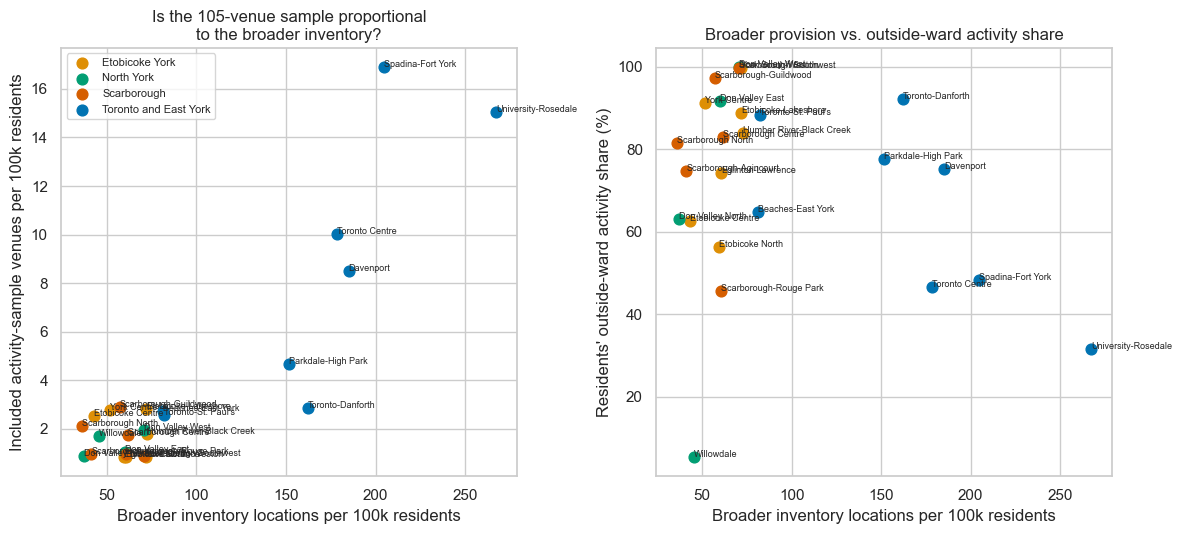


Wards with substantial broader inventory but 0-1 included activity-sample venues:


,ward_name,region,n_locations,locations_per_100k,n_activity_sample_venues
24,York South-Weston,Etobicoke York,84,71.94,1
13,Scarborough Southwest,Scarborough,79,70.54,1


In [31]:
# --- does the 105-venue sample disproportionately represent particular wards? --
rep_check = ward_inventory.merge(ward_reach[["ward_name", "region", "origin_outside_ward_share"]], on="ward_name")
corr_pairs = [
    ("n_activity_sample_venues", "n_locations", "included venues vs. broader location count"),
    ("n_activity_sample_venues", "locations_per_100k", "included venues vs. broader locations per 100k"),
    ("venues_per_100k", "locations_per_100k", "included venues per 100k vs. broader locations per 100k"),
    ("n_activity_sample_venues", "n_tac_funded", "included venues vs. TAC-funded-activity location count"),
]
rep_check_full = rep_check.merge(ward_reach[["ward_name", "venues_per_100k"]], on="ward_name")
print("Representativeness correlations (Spearman):")
for a, b, label in corr_pairs:
    rho, p = spearmanr(rep_check_full[a], rep_check_full[b])
    print(f"  {label}: rho={rho:.2f}, p={p:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for region, grp in rep_check_full.groupby("region"):
    axes[0].scatter(grp["locations_per_100k"], grp["venues_per_100k"], label=region, color=REGION_COLORS.get(region), s=60)
    axes[1].scatter(grp["locations_per_100k"], grp["origin_outside_ward_share"] * 100, label=region, color=REGION_COLORS.get(region), s=60)
for _, row in rep_check_full.iterrows():
    axes[0].annotate(row["ward_name"], (row["locations_per_100k"], row["venues_per_100k"]), fontsize=6.5)
    axes[1].annotate(row["ward_name"], (row["locations_per_100k"], row["origin_outside_ward_share"] * 100), fontsize=6.5)
axes[0].set_xlabel("Broader inventory locations per 100k residents")
axes[0].set_ylabel("Included activity-sample venues per 100k residents")
axes[0].set_title("Is the 105-venue sample proportional\nto the broader inventory?")
axes[1].set_xlabel("Broader inventory locations per 100k residents")
axes[1].set_ylabel("Residents' outside-ward activity share (%)")
axes[1].set_title("Broader provision vs. outside-ward activity share")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# wards with many broader locations but few/no activity-sample venues
print("\nWards with substantial broader inventory but 0-1 included activity-sample venues:")
rep_check_full[(rep_check_full["n_locations"] >= rep_check_full["n_locations"].median()) & (rep_check_full["n_activity_sample_venues"] <= 1)][
    ["ward_name", "region", "n_locations", "locations_per_100k", "n_activity_sample_venues"]
].sort_values("n_locations", ascending=False)


**Findings.**
- Coordinate matching (75m tolerance, no shared ID/name field available) finds a broader-inventory match for 94 of the 105 activity-sample venues; 11 have no nearby broader-inventory entry, and 38 of the 94 matches are ambiguous (more than one broader-inventory candidate within tolerance) — we report this as a limitation rather than forcing a 1:1 match.
- The 105-venue activity sample is **significantly positively correlated** with the broader inventory across wards: included-venue count vs. broader location count (ρ=0.66), population-adjusted versions (ρ=0.61–0.65), and TAC-funded-location count (ρ=0.67), all p<0.001. **This is reassuring for the flow analysis**: the 105-venue sample is not badly skewed toward downtown or away from suburban wards relative to the broader inventory — cross-ward flow findings are unlikely to be primarily an artifact of *which* venues happen to be in the activity sample.
- Two wards stand out as having **substantial broader cultural infrastructure but almost no activity-sample coverage**: **York South-Weston** (84 locations, 72/100k, only 1 included venue) and **Scarborough Southwest** (79 locations, 71/100k, only 1 included venue). For these two wards specifically, the flow findings in Sections 3–5 should be read as describing *one venue's* pattern, not the ward's cultural activity broadly.
- Funding-frequency and free-programming levels vary by ward (e.g., Spadina-Fort York and University-Rosedale have the highest shares of "high/very_high" funding frequency among TAC-funded locations, 17–19%; Scarborough-Agincourt and Scarborough Southwest the lowest, 1–3%), but we do not build a composite score from this — it is reported as descriptive context only.

**Takeaway.** The broader inventory **strengthens** the story's credibility (the activity sample is not obviously unrepresentative) while also **sharpening two specific caveats**: York South-Weston and Scarborough Southwest's flow numbers rest on a single venue each, and should be presented with that caveat attached rather than as ward-wide claims.

**Story implication.** Use the representativeness correlation (ρ≈0.6–0.7, p<0.001) as a one-line credibility check for the whole story, not as a headline finding itself. Name York South-Weston and Scarborough Southwest explicitly wherever their single-venue results are cited.


## 8. Focused demographic analysis

We test a small, hypothesis-led set of general-census measures against the reach measures built above — not an exhaustive fishing exercise. With only 25 wards, we report Spearman correlations with leave-one-out ranges, and treat every relationship as **ecological**: a ward-level association describes wards, not the individuals whose activity was observed. We do not build a predictive model or a composite accessibility index.


In [32]:
# --- assemble a small demographic table (all 2021 census reference period, income 2020) --
DEMO_CHARACTERISTICS = {
    113: "median_total_income_2020", 1414: "households_total", 1416: "renter_count",
    40: "median_age", 1683: "vis_minority_universe", 1684: "vis_minority_count",
    1998: "education_universe", 2008: "bachelor_or_higher_count",
}
demo_wide = census_long[census_long["CHARACTERISTIC_ID"].isin(DEMO_CHARACTERISTICS)].pivot_table(
    index="ward_name", columns="CHARACTERISTIC_ID", values="C1_COUNT_TOTAL", aggfunc="first"
).rename(columns=DEMO_CHARACTERISTICS).reset_index()
demo_wide["renter_share"] = demo_wide["renter_count"] / demo_wide["households_total"]
demo_wide["visible_minority_share"] = demo_wide["vis_minority_count"] / demo_wide["vis_minority_universe"]
demo_wide["bachelor_or_higher_share"] = demo_wide["bachelor_or_higher_count"] / demo_wide["education_universe"]

demo_table = ward_reach_transport.merge(demo_wide, on="ward_name").merge(
    ward_inventory[["ward_name", "locations_per_100k"]], on="ward_name")
print(f"demo_table: {demo_table.shape}")
demo_table[["ward_name", "median_total_income_2020", "renter_share", "median_age", "visible_minority_share", "bachelor_or_higher_share"]].describe().round(2)


demo_table: (25, 45)


,median_total_income_2020,renter_share,median_age,visible_minority_share,bachelor_or_higher_share
count,25.00,25.00,25.00,25.00,25.00
mean,"40,160.00",0.46,40.26,0.56,0.40
std,"7,146.79",0.11,2.79,0.20,0.13
min,"30,400.00",0.21,32.80,0.29,0.18
25%,"34,400.00",0.43,38.40,0.36,0.29
50%,"37,200.00",0.46,40.80,0.57,0.38
75%,"45,600.00",0.52,41.60,0.74,0.51
max,"58,400.00",0.70,45.60,0.92,0.65


In [33]:
# --- hypothesis-led correlations: demographic measures vs. reach measures --
DEMO_HYPOTHESES = [
    ("median_total_income_2020", "origin_outside_ward_share", "Median income (2020) vs. residents' outside-ward share"),
    ("renter_share", "origin_outside_ward_share", "Renter share vs. residents' outside-ward share"),
    ("median_age", "origin_outside_ward_share", "Median age vs. residents' outside-ward share"),
    ("visible_minority_share", "origin_outside_ward_share", "Visible minority share vs. residents' outside-ward share"),
    ("bachelor_or_higher_share", "origin_outside_ward_share", "Bachelor's-or-higher share vs. residents' outside-ward share"),
    ("population_density", "dest_effective_n", "Population density vs. destination effective-N (reach)"),
    ("locations_per_100k", "origin_outside_ward_share", "Broader location provision per 100k vs. residents' outside-ward share"),
    ("median_total_income_2020", "origin_to_suburb_share", "Median income (2020) vs. suburb-oriented outside-ward share"),
]

demo_results = []
for x, y, title in DEMO_HYPOTHESES:
    rho, p = spearmanr(demo_table[x], demo_table[y])
    demo_results.append({"x": x, "y": y, "title": title, "spearman_rho": rho, "p_value": p})
demo_results_df = pd.DataFrame(demo_results)
print(demo_results_df[["title", "spearman_rho", "p_value"]].to_string(index=False))


                                                                title  spearman_rho  p_value
               Median income (2020) vs. residents' outside-ward share         -0.15     0.49
                       Renter share vs. residents' outside-ward share          0.11     0.59
                         Median age vs. residents' outside-ward share          0.28     0.18
             Visible minority share vs. residents' outside-ward share         -0.06     0.79
         Bachelor's-or-higher share vs. residents' outside-ward share         -0.31     0.14
               Population density vs. destination effective-N (reach)         -0.51     0.01
Broader location provision per 100k vs. residents' outside-ward share         -0.03     0.90
          Median income (2020) vs. suburb-oriented outside-ward share         -0.59     0.00


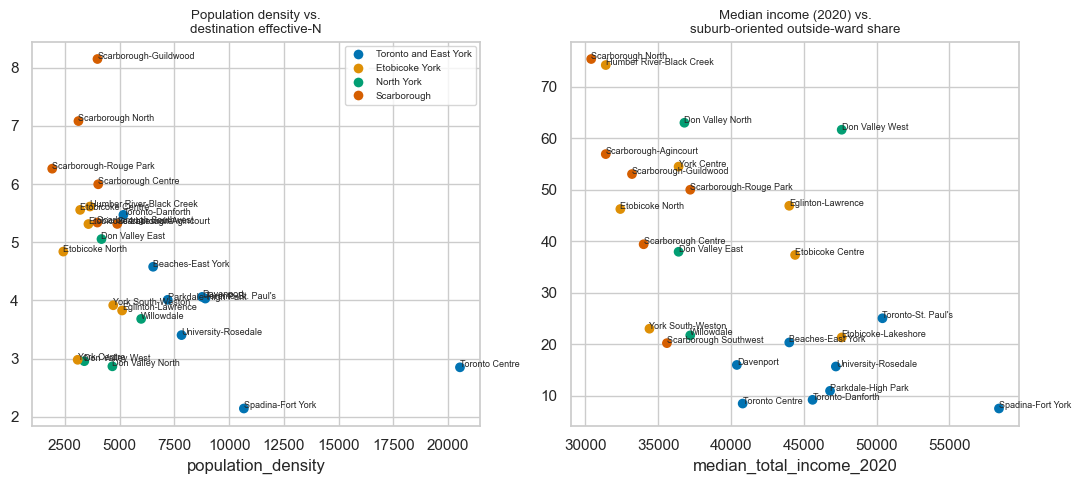

density vs. effective-N: full rho=-0.51, leave-one-out range=[-0.63, -0.45]
income vs. suburb-share (all 25 wards): full rho=-0.59, leave-one-out range=[-0.71, -0.54]
income vs. suburb-share, SUBURBAN WARDS ONLY (n=17): rho=-0.39, p=0.121 (confirms the citywide relationship)


In [34]:
# --- the two statistically significant relationships get a closer look -----
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (x, y, title) in zip(axes, [("population_density", "dest_effective_n", "Population density vs.\ndestination effective-N"),
                                      ("median_total_income_2020", "origin_to_suburb_share", "Median income (2020) vs.\nsuburb-oriented outside-ward share")]):
    ax.scatter(demo_table[x], demo_table[y] if y != "origin_to_suburb_share" else demo_table[y] * 100,
                c=demo_table["region"].map(REGION_COLORS))
    for _, row in demo_table.iterrows():
        yv = row[y] * 100 if y == "origin_to_suburb_share" else row[y]
        ax.annotate(row["ward_name"], (row[x], yv), fontsize=6.5)
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel(x)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=r, markersize=8) for r, c in REGION_COLORS.items()]
axes[0].legend(handles=handles, fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

# leave-one-out for both, plus a check of the income/suburb-share relationship WITHIN suburban wards only
# (region is a plausible confound: downtown wards are higher-income AND structurally have low
# origin_to_suburb_share simply because "outside ward" for them mostly means "another downtown ward")
for x, y, label in [("population_density", "dest_effective_n", "density vs. effective-N"),
                      ("median_total_income_2020", "origin_to_suburb_share", "income vs. suburb-share (all 25 wards)")]:
    rho_full, _ = spearmanr(demo_table[x], demo_table[y])
    loo = [spearmanr(demo_table.loc[demo_table["ward_name"] != w, x], demo_table.loc[demo_table["ward_name"] != w, y])[0]
           for w in demo_table["ward_name"]]
    print(f"{label}: full rho={rho_full:.2f}, leave-one-out range=[{min(loo):.2f}, {max(loo):.2f}]")

suburban_only = demo_table[demo_table["region"] != "Toronto and East York"]
rho_sub, p_sub = spearmanr(suburban_only["median_total_income_2020"], suburban_only["origin_to_suburb_share"])
print(f"income vs. suburb-share, SUBURBAN WARDS ONLY (n={len(suburban_only)}): rho={rho_sub:.2f}, p={p_sub:.3f} "
      f"({'confirms' if abs(rho_sub) > 0.3 else 'does NOT confirm, likely a region-composition confound'} the citywide relationship)")


**Findings.**
- Most of the 8 hypothesis-led demographic relationships are **weak and not statistically significant**: income, renter share, median age, visible minority share, bachelor's-or-higher share, and broader location provision all show |ρ| ≤ 0.31 against residents' outside-ward activity share (all p > 0.1). We do **not** report these as findings.
- Two relationships are statistically significant and stable under leave-one-out: **population density vs. destination effective-N** (ρ=-0.51, p=0.01; leave-one-out range [-0.63, -0.45] — denser wards' venues draw from a *narrower* set of origin wards, not a broader one) and **median income vs. suburb-oriented outside-ward share** (ρ=-0.59, p<0.01; leave-one-out range [-0.71, -0.54] — higher-income wards send a smaller share of their outside-ward activity to other suburban wards, and more to downtown).
- The income relationship is **partly, not fully, a region composition confound**: restricted to the 17 suburban wards only (removing downtown wards, which are both higher-income and structurally more likely to send outside-ward activity to *other downtown wards*), the relationship weakens but keeps its direction (ρ=-0.39, p=0.12, no longer significant at n=17). We report this as a real but modest pattern among suburban wards, not as strong as the citywide number alone would suggest.

**Takeaway.** With 25 wards, most simple demographic explanations for cross-ward activity do not hold up; the two exceptions are worth a cautious mention, but both require the ecological caveat explicitly: these describe *wards*, not the income or density of the specific people generating the observed activity.

**Story implication.** **Omit** income, renter share, age, visible-minority share, education and broader-provision as headline demographic drivers — they are not supported at 25 wards. If a demographic angle is wanted at all, the density/reach and income/suburb-orientation relationships are the only defensible candidates, and should be framed as "wards with X tend to show Y" observations, not explanations, with the confound check disclosed.


## 9. Visual and story recommendations

### 1. Strongest primary visual
**The sorted within/outside stacked bar** (Section 3, first figure): one horizontal bar per ward, split into within-ward (blue) and outside-ward (orange) shares, sorted by outside-ward share, with a 50% reference line. It answers the central question — "does my ward's cultural activity stay in my ward?" — for all 25 councillors simultaneously, with no need for a legend beyond two colours.

### 2–4. Supporting visuals
- **Paired leaving/entering bar** (Section 3): shows the two-way relationship per ward; use for wards where a councillor asks "but who comes to *us*?"
- **Scarborough destination-composition stacked bar** (Section 5): the best single figure for the suburb-to-suburb argument, showing Scarborough North/Centre/Agincourt/Rouge Park's real internal network against Scarborough Southwest's downtown-oriented counter-example, side by side.
- **Region-to-region heatmap** (Section 4): a compact citywide overview for an audience that wants the "big picture" before drilling into any one ward.

### 5. Headline statistics (with definitions)
- **52.0%** of normalized ward-mapped activity happens outside residents' home ward, citywide, activity-weighted (rises to **60.8%** excluding Meridian Arts Centre). *Definition: sum of outside-ward normalized raw-stop activity ÷ sum of all mapped normalized raw-stop activity.*
- **20 of 25 wards** (19 of 25 excluding Meridian) send a majority of residents' activity outside their own ward. *Definition: per-ward share of that ward's residents' total mapped activity occurring at venues outside the ward, unweighted count of wards above 50%.*
- **46%** of suburban residents' outside-ward activity goes to another suburban ward rather than downtown, robust to two different downtown-boundary definitions (46.2%/46.8%). *Definition: conditional on origin being an Etobicoke York/North York/Scarborough ward and destination being outside the origin ward, share of that activity landing in another Etobicoke York/North York/Scarborough ward.*
- Cross-ward activity travels a **weighted median of 6.2 km** (straight-line, home-area centre to venue); suburb-to-suburb activity (6.6 km) is shorter than suburb-to-downtown activity (11.3 km).

### 6. Best citywide example
**Don Valley West**: 100% of residents' recorded activity is outside the home ward, and the ward itself receives 85% of its venues' activity from outside — a genuine two-way "mutual exchange hub" with no anchor-venue concentration issue muddying the story (contrast with Willowdale/Meridian, which needs the anchor-venue caveat attached every time it's used).

### 7. Best Scarborough/suburban example
**Scarborough North → Scarborough-Agincourt**: Scarborough North sends more of its residents' outside-ward activity to other Scarborough wards (38.3%) than to North York or downtown, and Scarborough-Agincourt is the clearest regional node (681 normalized units received from other Scarborough wards, more than double the next ward) — and this pattern survives excluding the single largest Scarborough venue (Malvern Library).

### 8. Most useful broader-inventory finding
The 105-venue activity sample correlates significantly with the broader ~2,576-location inventory across wards (ρ=0.61–0.67, p<0.001) — **the flow results are not primarily an artifact of sample composition**. The named exception — **York South-Weston and Scarborough Southwest**, each with 70+ broader locations but only one activity-sample venue — should carry an explicit single-venue caveat wherever cited.

### 9. Demographic/transportation relationships strong enough to include
Only two, and both with caveats: **population density vs. destination reach** (ρ=-0.51, stable under leave-one-out) and **income vs. suburban-orientation of outside-ward activity** (ρ=-0.59 citywide, weakens to ρ=-0.39 within suburban wards only — a real but partly region-confounded pattern). Neither is strong enough to be a headline finding; both are optional footnotes at most.

### Findings that should be omitted
- All transit/car-commute-share and long-commute-share correlations against outside-ward activity (weak, p>0.05, unstable under leave-one-out for the one borderline case).
- Renter share, median age, visible minority share, bachelor's-or-higher share, and broader-location-provision-per-capita as demographic "explanations" — none reach significance at 25 wards.
- Any reciprocal-ward-pair claim with reciprocity below ~0.15 (e.g., Don Valley West↔Willowdale, Willowdale↔York Centre) should not be called a "two-way exchange" — it is one ward's residents visiting a dominant venue elsewhere with negligible return flow.

### Main caveats for the published story
1. Normalized activity is **not** attendance, a unique-person count, or a percentage of residents participating.
2. The 105 venues are a **study sample**, not an exhaustive list; the 2,576-location inventory has no activity data attached.
3. Ward-level demographic relationships are **ecological** and describe wards, not individual visitors.
4. Crossing a ward line does not, by itself, demonstrate inadequate local access; distance is not the same as difficulty.
5. Willowdale's within-ward concentration is substantially a single-venue (Meridian Arts Centre) effect.


### Preliminary story sequence (one coherent story, ~5 sections)

The task instructions ask us to keep the two central claims together as one story, not split into separate cultural-workforce or anchor-venue pieces. Proposed sequence:

1. **Opening claim + headline number**: "Cultural venues already serve residents across ward lines" — lead with the sorted stacked bar and the 52.0%/20-of-25 statistics.
2. **The two-way relationship**: introduce "your residents leave, and others arrive" using the paired bar and 1–2 concrete ward examples (Don Valley West as the clean two-way hub).
3. **It's not just downtown**: the suburb-to-suburb finding (46%), region-to-region heatmap, with the Willowdale/Meridian caveat named explicitly as a single-venue qualifier.
4. **Case study: Scarborough as a real regional network**: Scarborough North/Centre/Agincourt/Rouge Park, the stacked composition bar, Scarborough-Agincourt as the node, and the distance evidence (4.3 km median vs. 12–13 km to North York/downtown) — with Scarborough Southwest named as the honest counter-example.
5. **What this means, and what's still open**: councillor-facing implications, the broader-inventory credibility check, and the caveats list.

### Visual specification table

| Visual | Question answered | Form | Variables | Annotation | Why preferred | Role |
|---|---|---|---|---|---|---|
| Sorted within/outside bar | Does my ward's activity stay local? | Horizontal stacked bar, sorted | `origin_within_ward_share`, `origin_outside_ward_share` | 50% reference line | One bar per ward, immediately locatable by any councillor | Headline |
| Paired leaving/entering bar | Who visits whom? | Grouped horizontal bar | `origin_outside_ward_share`, `dest_outside_ward_share` | 50% reference line | Shows both directions without a matrix | Supporting |
| Scarborough composition stacked bar | Does Scarborough form one network? | Stacked bar, 6 wards | same/other-Scarborough/NY-Willowdale/downtown/elsewhere shares | none needed, legend suffices | Direct visual test of the regional-network claim | Case-study |
| Region-to-region heatmap | Where does activity flow between regions? | Annotated heatmap, 4x4 | region-to-region % of origin's activity | row-normalized % | Compact citywide overview | Supporting |
| Origin/destination quadrant | Which wards are hubs vs. exporters vs. destinations vs. local? | Scatter with median lines | `origin_outside_ward_share`, `dest_outside_ward_share`, venue count | median reference lines | Avoids a composite score while showing both axes at once | Supporting/discussion |

### Findings ready for story development
- 52.0% (60.8% ex-Meridian) of normalized ward-mapped activity happens outside residents' home ward; 20 of 25 (19 of 25 ex-Meridian) wards send a majority outside.
- 46% of suburban residents' outside-ward activity goes to another suburban ward, stable across two downtown-boundary definitions.
- Scarborough North/Centre/Agincourt/Rouge Park form a genuine multi-venue internal network (survives excluding the largest venue); Scarborough-Agincourt is the clearest regional node; Scarborough Southwest is a legitimate downtown-oriented counter-example within the same borough.
- Cross-ward and suburb-to-suburb activity happen at plausible, moderate straight-line distances (6.2–6.6 km medians), shorter than suburb-to-downtown (11.3 km).
- The 105-venue activity sample is not badly unrepresentative of the broader ~2,576-location cultural inventory (ρ=0.61–0.67, p<0.001) — with York South-Weston and Scarborough Southwest flagged as single-venue exceptions.

### Questions requiring additional analysis or data
- **Why** suburb-to-suburb trips happen at their observed distances (mode choice, actual travel time) — needs **GTFS-based transit travel-time data** or venue-level mode-choice information; census commute variables do not answer this.
- Whether the 11 activity-sample venues with no broader-inventory match (Section 7) reflect a genuine gap in the broader inventory's collection or a geocoding mismatch — needs a **name-level reconciliation** between the two location files (neither currently shares a stable ID).
- Whether Meridian Arts Centre's home-origin concentration reflects genuine draw or a nearby-activity artifact (transit hub, adjacent mall) — flagged but not resolved here; would need venue-level device-trace review, out of scope for this notebook.
- Whether funding metadata (`tac_funded_operator/resident/programming` on the 105-venue file, or `funding_frequency` on the broader inventory) is associated with cross-ward reach — not tested here because a defensible funding-equity claim needs dollar amounts, not yes/no flags; the columns exist but were not analyzed as a driver in this notebook.
